# Deep Learning: Basics to Expert

A single, self-contained course on **deep learning** — from a lone artificial neuron to
backpropagation, convolutional networks, LSTMs, attention and Transformers, GANs, and
production training craft. Every core idea is first **implemented from scratch in NumPy**,
then rebuilt with **PyTorch** the way practitioners actually do it.
(For a tour of the PyTorch *library* itself, see `pytorch_basics_to_expert.ipynb` in this series.)

**How to read this notebook:** every section builds one idea, shows the math, codes it from
first principles, and ends with the production-grade equivalent. Everything runs on CPU in a
few minutes. Run cells top to bottom.

### Contents
| Part | Sections |
|---|---|
| **I — Foundations** | [1. What is deep learning?](#1) · [2. The artificial neuron](#2) · [3. Activation functions](#3) · [4. From neuron to network](#4) · [5. Loss functions](#5) |
| **II — How networks learn** | [6. Gradient descent & the loss landscape](#6) · [7. Backpropagation from scratch](#7) · [8. Mini-batches & SGD](#8) · [9. Optimizers: momentum, RMSProp, Adam](#9) · [10. Autograd: how frameworks do it](#10) |
| **III — Training craft** | [11. The PyTorch training loop](#11) · [12. Weight initialization](#12) · [13. Regularization](#13) · [14. Batch normalization](#14) · [15. Learning-rate schedules](#15) |
| **IV — Architectures** | [16. Convolutional networks](#16) · [17. Recurrent networks](#17) · [18. LSTMs & gating](#18) · [19. Embeddings](#19) · [20. Attention from scratch](#20) · [21. A tiny Transformer](#21) |
| **V — Beyond classification** | [22. Autoencoders](#22) · [23. Generative adversarial networks](#23) · [24. Transfer learning & self-supervised pretraining](#24) |
| **VI — Expert practice** | [25. Debugging neural networks](#25) · [26. Custom autograd & gradient checking](#26) · [27. Saving, loading & exporting](#27) · [28. Capstone: a full training pipeline](#28) · [29. Where to go from here](#29) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
import torch
import torch.nn as nn
import torch.nn.functional as F
import sklearn

print("numpy:", np.__version__, "| torch:", torch.__version__, "| scikit-learn:", sklearn.__version__)

# One fixed, colorblind-safe categorical palette used throughout the notebook
# (assigned in this fixed order, never re-shuffled per chart).
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
           "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
GRAY = "#898781"

plt.rcParams.update({
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "xtick.color": GRAY, "ytick.color": GRAY,
    "figure.dpi": 100, "figure.facecolor": "white",
})

rng = np.random.default_rng(42)   # one seeded generator for the whole notebook
torch.manual_seed(42);

numpy: 2.3.1 | torch: 2.4.1+cpu | scikit-learn: 1.7.2


<a id="1"></a>
## 1. What is deep learning?

Classical machine learning: a human designs the **features** (edge counts, word frequencies,
ratios...) and a model fits weights on top of them. Deep learning: the model **learns the
features itself**, as a hierarchy of simple transformations — layer 1 learns edges, layer 2
learns shapes made of edges, layer 3 learns objects made of shapes. "Deep" simply means
*many layers of learned representation*.

Why it matters: for raw signals (pixels, audio, text) nobody knows how to hand-design good
features. Depth + data + gradient descent finds them automatically. Here is the effect on a
dataset where no straight line — and no hand-obvious feature — separates the classes.

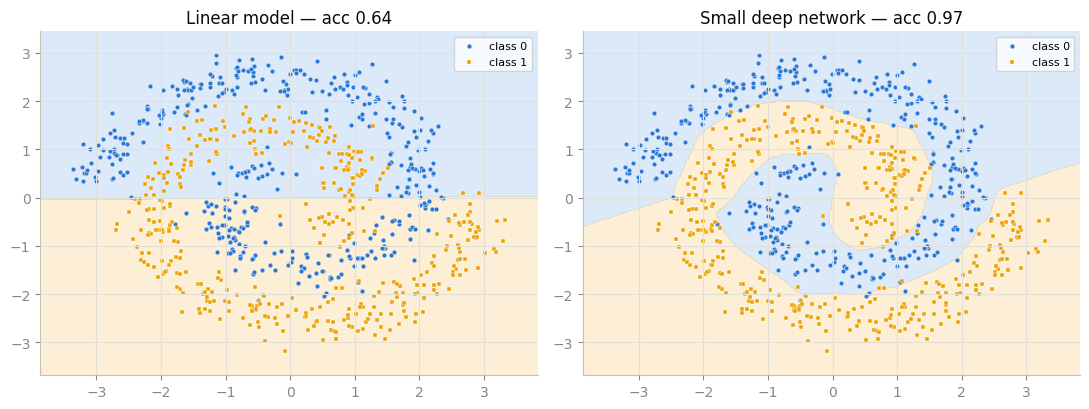

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# A two-armed spiral: the classic "you can't draw a line through this" dataset
def make_spiral(n=400, noise=0.25):
    t = np.sqrt(rng.uniform(0.25, 9, n))          # radius grows along the arm
    a = t * np.pi
    X0 = np.c_[t*np.cos(a),  t*np.sin(a)] + rng.normal(0, noise, (n, 2))
    X1 = np.c_[t*np.cos(a+np.pi), t*np.sin(a+np.pi)] + rng.normal(0, noise, (n, 2))
    return np.vstack([X0, X1]), np.r_[np.zeros(n), np.ones(n)].astype(int)

Xs, ys = make_spiral()

def plot_regions(model, X, y, ax, title):
    '''Paint a fitted model's decision regions behind the data.'''
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.5, X[:,0].max()+.5, 300),
                         np.linspace(X[:,1].min()-.5, X[:,1].max()+.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-.5,.5,1.5], colors=[PALETTE[0], PALETTE[2]], alpha=.16)
    for c, m in [(0,'o'), (1,'s')]:
        ax.scatter(*X[y==c].T, c=PALETTE[0] if c==0 else PALETTE[2], s=12, marker=m,
                   edgecolors='white', linewidths=.3, label=f"class {c}")
    ax.set_title(title); ax.legend(loc="upper right", fontsize=8)

lin = LogisticRegression().fit(Xs, ys)
net = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=0).fit(Xs, ys)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
plot_regions(lin, Xs, ys, ax1, f"Linear model — acc {lin.score(Xs, ys):.2f}")
plot_regions(net, Xs, ys, ax2, f"Small deep network — acc {net.score(Xs, ys):.2f}")
plt.tight_layout()

The linear model draws the best straight line and gives up at ~50%. The two-hidden-layer
network *bends space* until the spiral arms become separable — that bending is learned, not
programmed. The rest of this notebook is about how such a machine is built and trained.

<a id="2"></a>
## 2. The artificial neuron

One neuron computes a weighted sum plus a bias, then a nonlinearity:

$$\hat y = \phi(\mathbf{w}\cdot\mathbf{x} + b)$$

With a step function for $\phi$ this is the 1958 **perceptron**: a machine that draws one
straight line (a hyperplane in general) and answers "which side are you on?" That is enough
to implement OR — and famously *not* enough for XOR, which is why depth exists at all.

OR  truth table: [0 1 1 1] | neuron says: [0 1 1 1]


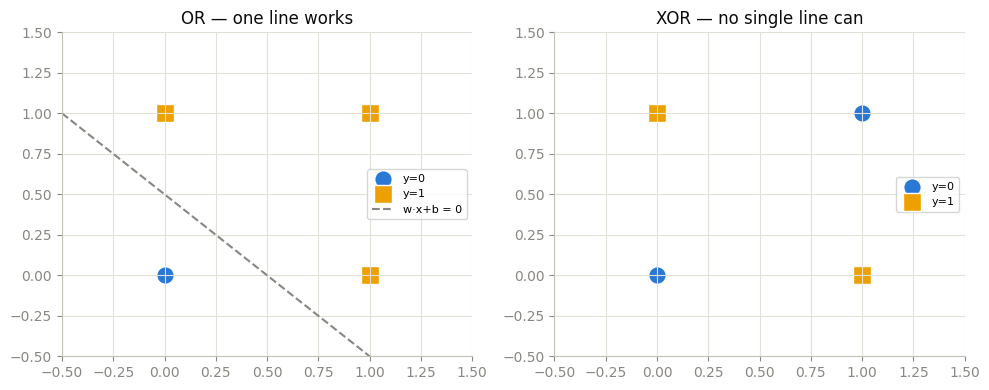

In [3]:
def neuron(x, w, b, phi=lambda z: (z > 0).astype(int)):
    return phi(x @ w + b)

X_gate = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or, y_xor = np.array([0,1,1,1]), np.array([0,1,1,0])

w_or, b_or = np.array([1.0, 1.0]), -0.5      # hand-set weights that implement OR
print("OR  truth table:", y_or, "| neuron says:", neuron(X_gate, w_or, b_or))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, name in [(ax1, y_or, "OR — one line works"), (ax2, y_xor, "XOR — no single line can")]:
    for c, m in [(0,'o'), (1,'s')]:
        ax.scatter(*X_gate[y==c].T, s=160, marker=m,
                   c=PALETTE[0] if c==0 else PALETTE[2], edgecolors='white', label=f"y={c}")
    ax.set_xlim(-.5, 1.5); ax.set_ylim(-.5, 1.5); ax.set_title(name); ax.legend(loc="center right", fontsize=8)
xs = np.linspace(-.5, 1.5, 2)
ax1.plot(xs, (0.5 - xs), color=GRAY, ls="--", label="w·x+b = 0")   # x1 + x2 = 0.5
ax1.legend(loc="center right", fontsize=8)
plt.tight_layout()

On the left, the dashed line $\mathbf w\cdot\mathbf x + b = 0$ puts the three positive
points on one side. On the right there is provably no such line — you need *two* lines and a
combiner, i.e. a **hidden layer**. (This XOR argument, from Minsky & Papert 1969, froze
neural-net research for a decade until backprop made multi-layer training practical.)

<a id="3"></a>
## 3. Activation functions

The nonlinearity $\phi$ is the whole reason networks can bend space. The step function has a
useless derivative (zero everywhere), so training needs smooth-ish alternatives. The classics:

- **sigmoid** $\sigma(z)=1/(1+e^{-z})$ — squashes to $(0,1)$; saturates (gradient → 0) at both ends
- **tanh** — zero-centered sigmoid; still saturates
- **ReLU** $\max(0,z)$ — the modern default: cheap, non-saturating for $z>0$, but can "die" at $z<0$
- **LeakyReLU** — gives the negative side a small slope so gradients never fully vanish
- **GELU** — a smooth ReLU used by Transformers (BERT, GPT)

Their **derivatives** matter as much as their shapes: training multiplies these derivatives
layer after layer (§7, §12), so flat regions kill learning.

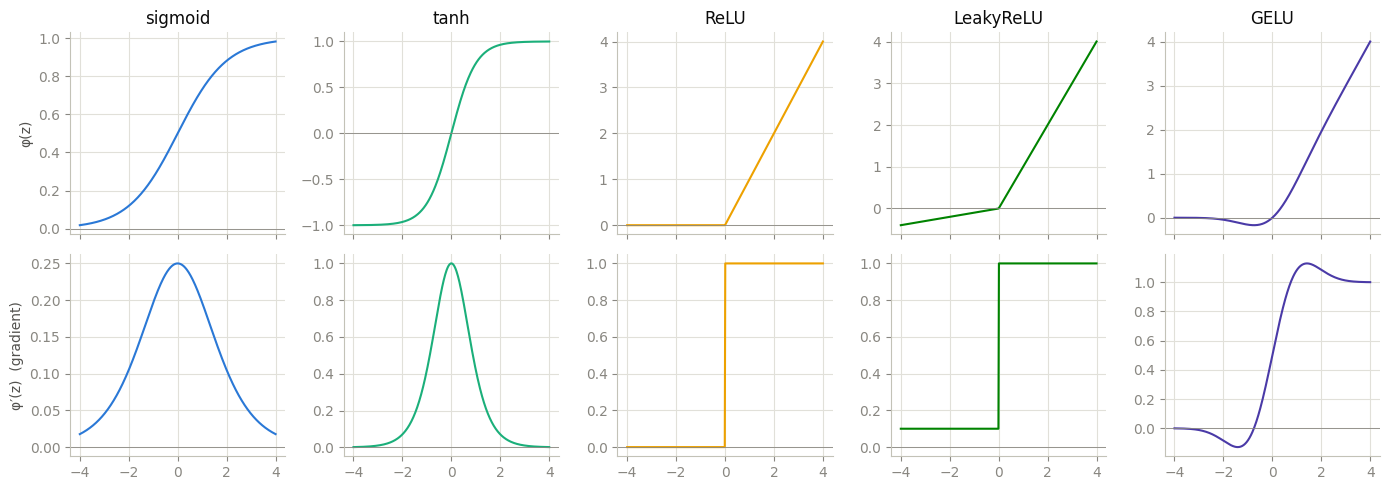

In [4]:
from scipy.special import erf

z = np.linspace(-4, 4, 400)
acts = {
    "sigmoid":   (1/(1+np.exp(-z)),           (1/(1+np.exp(-z)))*(1-1/(1+np.exp(-z)))),
    "tanh":      (np.tanh(z),                  1-np.tanh(z)**2),
    "ReLU":      (np.maximum(0, z),            (z > 0).astype(float)),
    "LeakyReLU": (np.where(z > 0, z, .1*z),    np.where(z > 0, 1, .1)),
    "GELU":      (.5*z*(1+erf(z/np.sqrt(2))),
                  .5*(1+erf(z/np.sqrt(2))) + z*np.exp(-z**2/2)/np.sqrt(2*np.pi)),
}
fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharex=True)
for i, (name, (f_, df)) in enumerate(acts.items()):
    axes[0, i].plot(z, f_, color=PALETTE[i]); axes[0, i].set_title(name)
    axes[1, i].plot(z, df, color=PALETTE[i])
    axes[0, i].axhline(0, color=GRAY, lw=.6); axes[1, i].axhline(0, color=GRAY, lw=.6)
axes[0, 0].set_ylabel("φ(z)"); axes[1, 0].set_ylabel("φ′(z)  (gradient)")
plt.tight_layout()

**Why nonlinearity is mandatory:** stack linear layers without any $\phi$ and the whole
network collapses into one linear layer — depth buys you nothing. Proof by computation:

In [5]:
W1, W2, W3 = rng.normal(size=(4,8)), rng.normal(size=(8,8)), rng.normal(size=(8,2))
x = rng.normal(size=(5,4))

deep_linear   = x @ W1 @ W2 @ W3          # "3-layer network", no activations
one_layer     = x @ (W1 @ W2 @ W3)        # a single equivalent matrix
print("3 linear layers == 1 linear layer:", np.allclose(deep_linear, one_layer))
print("=> without activations, a 100-layer net is exactly as expressive as logistic regression.")

3 linear layers == 1 linear layer: True
=> without activations, a 100-layer net is exactly as expressive as logistic regression.


<a id="4"></a>
## 4. From neuron to network: the forward pass

Stack neurons side by side into a **layer** (a matrix multiply), stack layers into a network
(a **multi-layer perceptron**, MLP). For a 2-layer classifier:

$$\mathbf{h} = \tanh(X W_1 + \mathbf{b}_1) \qquad \hat y = \sigma(\mathbf{h}\, W_2 + b_2)$$

The forward pass is just these two lines of code. An **untrained** network is a random
function — different random weights give different arbitrary decision regions. Training (§7)
is the process of turning that random function into the one you want.

a 2-16-1 MLP has 65 trainable parameters


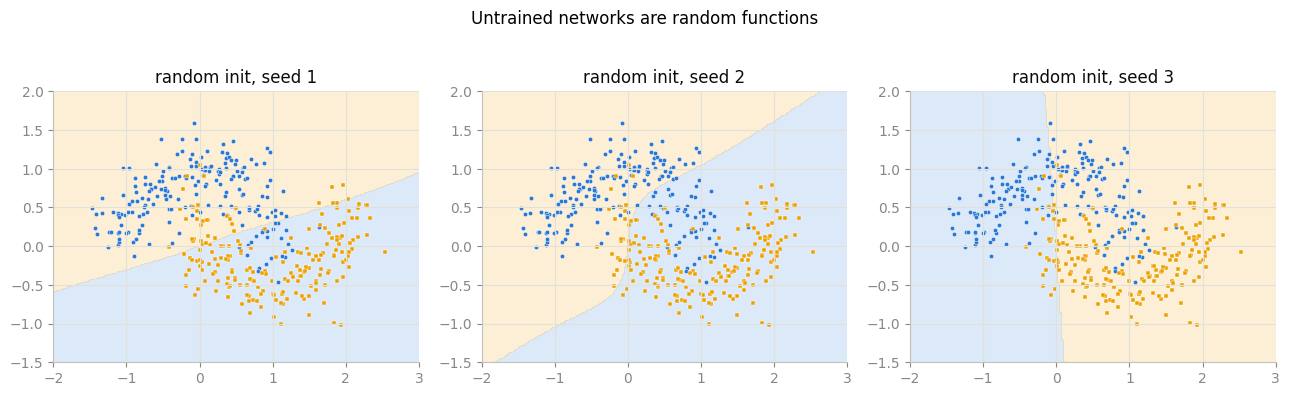

In [6]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(400, noise=0.25, random_state=0)

def init_params(n_in, n_hidden, n_out, seed):
    r = np.random.default_rng(seed)
    return {"W1": r.normal(0, 1, (n_in, n_hidden)), "b1": np.zeros(n_hidden),
            "W2": r.normal(0, 1, (n_hidden, n_out)), "b2": np.zeros(n_out)}

def forward(params, X):
    h = np.tanh(X @ params["W1"] + params["b1"])          # hidden layer
    p = 1/(1+np.exp(-(h @ params["W2"] + params["b2"])))  # output probability
    return p.ravel()

n_params = 2*16 + 16 + 16*1 + 1
print(f"a 2-16-1 MLP has {n_params} trainable parameters")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, seed in zip(axes, [1, 2, 3]):
    params = init_params(2, 16, 1, seed)
    xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
    Z = forward(params, np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z > .5, levels=[-.5,.5,1.5], colors=[PALETTE[0], PALETTE[2]], alpha=.16)
    for c, m in [(0,'o'), (1,'s')]:
        ax.scatter(*Xm[ym==c].T, c=PALETTE[0] if c==0 else PALETTE[2], s=10, marker=m,
                   edgecolors='white', linewidths=.3)
    ax.set_title(f"random init, seed {seed}")
plt.suptitle("Untrained networks are random functions", y=1.03)
plt.tight_layout()

<a id="5"></a>
## 5. Loss functions: the training signal

A **loss function** scores how wrong the network is on one batch; training is nothing but
*minimizing that number*. The choice of loss defines the task:

| Task | Output layer | Loss |
|---|---|---|
| regression | linear | MSE $\;(\hat y - y)^2$, or Huber if outliers |
| binary classification | sigmoid | binary cross-entropy $-[y\log\hat y + (1-y)\log(1-\hat y)]$ |
| multi-class | softmax | cross-entropy $-\log \hat p_{\text{true class}}$ |

Cross-entropy deserves the plot below: it punishes *confident wrong* answers brutally
(loss → ∞ as the probability on the true class → 0), which is exactly the gradient signal
a classifier needs.

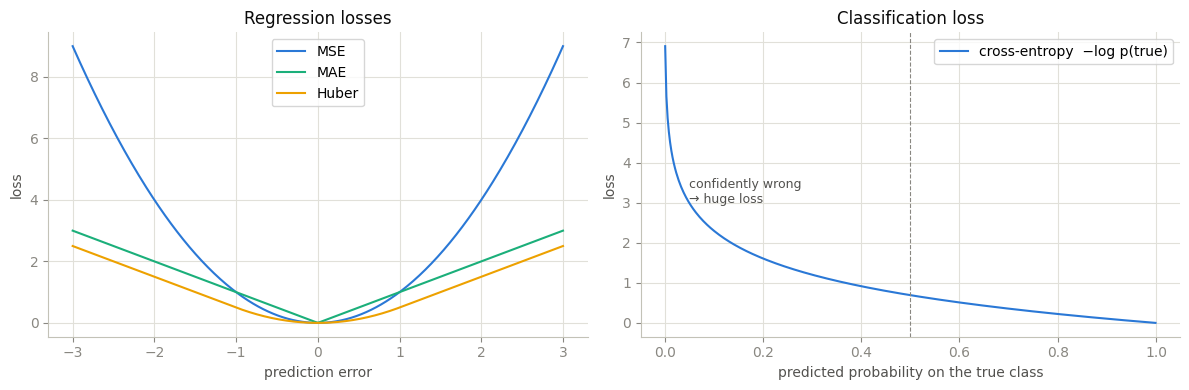

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

e = np.linspace(-3, 3, 400)                       # regression: error = prediction - target
huber = np.where(np.abs(e) <= 1, .5*e**2, np.abs(e) - .5)
ax1.plot(e, e**2, label="MSE"); ax1.plot(e, np.abs(e), label="MAE")
ax1.plot(e, huber, label="Huber")
ax1.set_xlabel("prediction error"); ax1.set_ylabel("loss")
ax1.set_title("Regression losses"); ax1.legend()

p = np.linspace(0.001, 0.999, 400)                # classification: prob on the true class
ax2.plot(p, -np.log(p), label="cross-entropy  −log p(true)")
ax2.axvline(0.5, color=GRAY, ls="--", lw=.8)
ax2.annotate("confidently wrong\n→ huge loss", xy=(.05, 3), fontsize=9, color="#52514e")
ax2.set_xlabel("predicted probability on the true class"); ax2.set_ylabel("loss")
ax2.set_title("Classification loss"); ax2.legend()
plt.tight_layout()

In [8]:
def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)       # subtract max: avoids exp() overflow
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

# One 3-class example, computed by hand
logits = np.array([2.0, 0.5, -1.0])             # raw network outputs ("scores")
probs  = softmax(logits)
true_class = 0
print("logits :", logits)
print("softmax:", probs.round(4), " (sums to", probs.sum().round(4), ")")
print(f"cross-entropy = -log p[true] = -log({probs[true_class]:.4f}) = {-np.log(probs[true_class]):.4f}")
print("\nSame numbers via PyTorch (expects raw logits, applies log-softmax internally):")
print("F.cross_entropy =", F.cross_entropy(torch.tensor(logits).unsqueeze(0),
                                           torch.tensor([true_class])).item())

logits : [ 2.   0.5 -1. ]
softmax: [0.7856 0.1753 0.0391]  (sums to 1.0 )
cross-entropy = -log p[true] = -log(0.7856) = 0.2413

Same numbers via PyTorch (expects raw logits, applies log-softmax internally):
F.cross_entropy = 0.24131129665715703


<a id="6"></a>
## 6. Gradient descent and the loss landscape

Picture the loss as a landscape over parameter space. The **gradient** $\nabla L$ points
uphill; gradient descent repeatedly steps downhill:

$$\theta \leftarrow \theta - \eta\, \nabla L(\theta)$$

The **learning rate** $\eta$ is the most important hyperparameter in deep learning:
too small → crawling; too large → oscillation or divergence. Watch all three regimes on a
valley that is 8× steeper in one direction than the other (realistic — loss surfaces are
badly scaled):

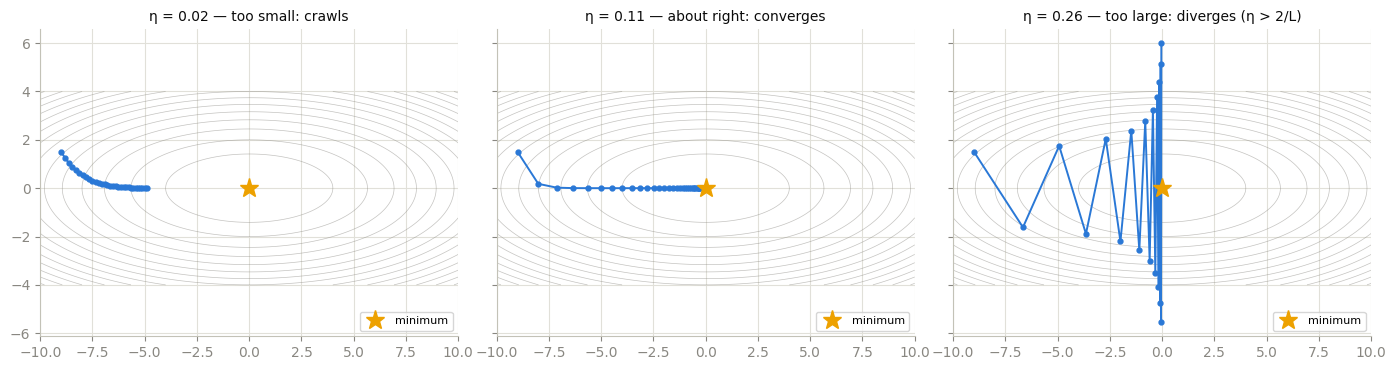

In [9]:
A = np.array([1.0, 8.0])                          # curvatures: shallow in x, steep in y
loss_f = lambda w: 0.5 * (A * w**2).sum()
grad_f = lambda w: A * w

def descend(lr, steps=30, w0=(-9.0, 1.5)):
    w, path = np.array(w0), [np.array(w0)]
    for _ in range(steps):
        w = w - lr * grad_f(w)
        path.append(w.copy())
    return np.array(path)

xx, yy = np.meshgrid(np.linspace(-10, 10, 200), np.linspace(-4, 4, 200))
zz = 0.5*(A[0]*xx**2 + A[1]*yy**2)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, lr, verdict in zip(axes, [0.02, 0.11, 0.26], ["too small: crawls",
                                                      "about right: converges",
                                                      "too large: diverges (η > 2/L)"]):
    path = descend(lr, steps=18 if lr > 0.2 else 30)
    ax.contour(xx, yy, zz, levels=15, colors=[GRAY], linewidths=.5, alpha=.5)
    ax.plot(*path.T, marker="o", ms=3.5, lw=1.4, color=PALETTE[0])
    ax.plot(0, 0, marker="*", ms=14, color=PALETTE[2], ls="none", label="minimum")
    ax.set_title(f"η = {lr} — {verdict}", fontsize=10); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()

The middle panel still **zigzags**: the steep direction forces a small η, which then crawls
along the shallow direction. This pathology — curvature that differs across directions — is
what momentum and Adam fix in §9. And unlike this bowl, real deep-net landscapes are
non-convex, with saddle points and countless valleys; remarkably, SGD finds good ones anyway.

<a id="7"></a>
## 7. Backpropagation from scratch

Gradient descent needs $\partial L/\partial\theta$ for *every* weight. **Backpropagation** is
just the chain rule, organized so each layer's gradient reuses the one after it. For our
2-layer net with sigmoid output $p$ and binary cross-entropy $L$, working backwards:

$$\underbrace{\frac{\partial L}{\partial z_2} = p - y}_{\text{beautifully simple}} \qquad
\frac{\partial L}{\partial W_2} = h^\top (p-y) \qquad
\frac{\partial L}{\partial h} = (p-y) W_2^\top \qquad
\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial h}\odot(1-h^2)$$

Each line reuses the previous one — that is the entire trick: gradients flow **backward**
through the same graph the data flowed forward through, one cheap pass for all parameters.

final loss 0.1539 | training accuracy 0.932


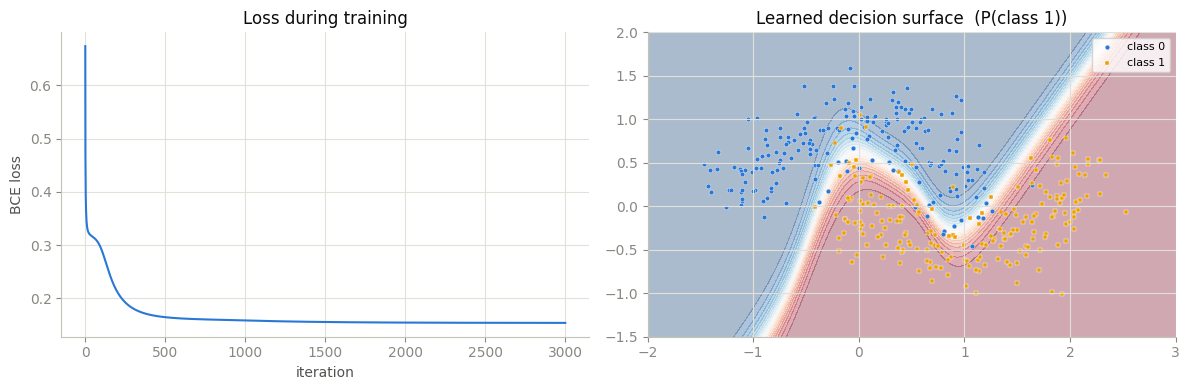

In [10]:
class TinyMLP:
    '''2-layer MLP for binary classification, trained by hand-written backprop.'''
    def __init__(self, n_in=2, n_hidden=16, seed=0):
        r = np.random.default_rng(seed)
        self.W1 = r.normal(0, 1/np.sqrt(n_in), (n_in, n_hidden)); self.b1 = np.zeros(n_hidden)
        self.W2 = r.normal(0, 1/np.sqrt(n_hidden), (n_hidden, 1)); self.b2 = np.zeros(1)

    def forward(self, X):
        self.X  = X
        self.h  = np.tanh(X @ self.W1 + self.b1)
        self.p  = 1/(1+np.exp(-(self.h @ self.W2 + self.b2)))
        return self.p.ravel()

    def backward(self, y):                      # returns dict of gradients
        N   = len(y)
        dz2 = (self.p - y[:, None]) / N                      # ∂L/∂z2  (BCE + sigmoid)
        dW2 = self.h.T @ dz2;      db2 = dz2.sum(0)
        dh  = dz2 @ self.W2.T
        dz1 = dh * (1 - self.h**2)                           # tanh'(z) = 1 - h²
        dW1 = self.X.T @ dz1;      db1 = dz1.sum(0)
        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

    def step(self, grads, lr):
        for k, g in grads.items():
            setattr(self, k, getattr(self, k) - lr * g)

def bce(p, y):
    p = np.clip(p, 1e-9, 1-1e-9)
    return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()

net = TinyMLP()
losses = []
for it in range(3000):
    p = net.forward(Xm)
    losses.append(bce(p, ym))
    net.step(net.backward(ym), lr=1.0)

acc = ((net.forward(Xm) > .5) == ym).mean()
print(f"final loss {losses[-1]:.4f} | training accuracy {acc:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses, color=PALETTE[0]); ax1.set_xlabel("iteration"); ax1.set_ylabel("BCE loss")
ax1.set_title("Loss during training")
xx, yy = np.meshgrid(np.linspace(-2, 3, 250), np.linspace(-1.5, 2, 250))
Z = net.forward(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax2.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=.35, vmin=0, vmax=1)
for c, m in [(0,'o'), (1,'s')]:
    ax2.scatter(*Xm[ym==c].T, c=PALETTE[0] if c==0 else PALETTE[2], s=12, marker=m,
                edgecolors='white', linewidths=.3, label=f"class {c}")
ax2.set_title("Learned decision surface  (P(class 1))"); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()

Compare with §4: the same architecture that was a random function is now a moon-shaped
classifier — 3000 tiny downhill steps did that. **Always verify hand-written gradients**
against finite differences $\;\partial L/\partial\theta \approx [L(\theta+\epsilon)-L(\theta-\epsilon)]/2\epsilon$:

In [11]:
def numerical_grad(net, X, y, param, eps=1e-6):
    W = getattr(net, param); G = np.zeros_like(W)
    it = np.nditer(W, flags=["multi_index"])
    for _ in it:
        i = it.multi_index
        W[i] += eps;  lp = bce(net.forward(X), y)
        W[i] -= 2*eps; lm = bce(net.forward(X), y)
        W[i] += eps
        G[i] = (lp - lm) / (2*eps)
    return G

check_net = TinyMLP(n_hidden=4, seed=1)
check_net.forward(Xm[:40]); analytic = check_net.backward(ym[:40])
for p in ["W1", "W2", "b1", "b2"]:
    num = numerical_grad(check_net, Xm[:40], ym[:40], p)
    rel = np.abs(num - analytic[p]).max() / (np.abs(num).max() + 1e-12)
    print(f"{p}: max relative error vs finite differences = {rel:.2e}")

W1: max relative error vs finite differences = 9.03e-10
W2: max relative error vs finite differences = 3.73e-10
b1: max relative error vs finite differences = 2.46e-09
b2: max relative error vs finite differences = 1.45e-10


<a id="8"></a>
## 8. Mini-batches and stochastic gradient descent

So far we computed the gradient on the **whole dataset** every step. Real datasets have
millions of examples — instead, estimate the gradient on a random **mini-batch**. The
estimate is noisy, but you take many more steps per unit of compute, and the noise even helps
escape saddle points. Batch size is a dial between two extremes:

- **batch = N** (full-batch GD): exact gradient, few expensive steps, smooth loss curve
- **batch = 1** (pure SGD): wildly noisy, cheap steps
- **batch = 32–512**: the practical sweet spot (also matches hardware parallelism)

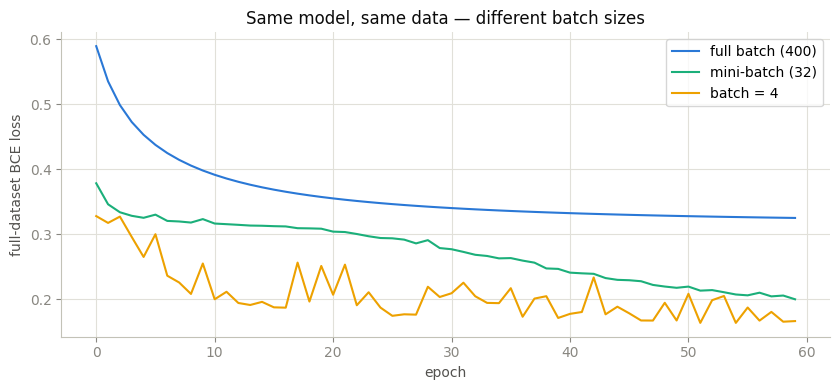

In [12]:
def train_batched(batch_size, epochs=60, lr=0.3, seed=0):
    net, r = TinyMLP(seed=seed), np.random.default_rng(seed)
    hist = []
    for _ in range(epochs):
        idx = r.permutation(len(Xm))
        for s in range(0, len(Xm), batch_size):
            b = idx[s:s+batch_size]
            net.forward(Xm[b]); net.step(net.backward(ym[b]), lr)
        hist.append(bce(net.forward(Xm), ym))      # full-data loss, once per epoch
    return hist

fig, ax = plt.subplots(figsize=(8.5, 4))
for bs, label in [(400, "full batch (400)"), (32, "mini-batch (32)"), (4, "batch = 4")]:
    ax.plot(train_batched(bs), label=label)
ax.set_xlabel("epoch"); ax.set_ylabel("full-dataset BCE loss")
ax.set_title("Same model, same data — different batch sizes"); ax.legend()
plt.tight_layout()

Per **epoch** (one pass over the data), smaller batches make more updates and typically
drop the loss faster at first, at the price of noise. Deep learning practice: pick the
largest batch that fits memory, then tune the learning rate to match.

<a id="9"></a>
## 9. Optimizers: momentum, RMSProp, Adam

Plain SGD zigzags across steep valleys (§6). Two fixes, both one line of state per parameter:

- **Momentum** — keep a running velocity $v \leftarrow \beta v + \nabla L$; step along $v$.
  Oscillations cancel, consistent directions accumulate. (Like a heavy ball rolling downhill.)
- **RMSProp** — divide each coordinate's step by the running RMS of its gradients, so steep
  coordinates get small steps and shallow ones get large steps.
- **Adam** = momentum + RMSProp + bias correction. The default optimizer of modern deep
  learning ($\beta_1{=}0.9$, $\beta_2{=}0.999$).

All three, from scratch, racing on the badly-scaled valley:

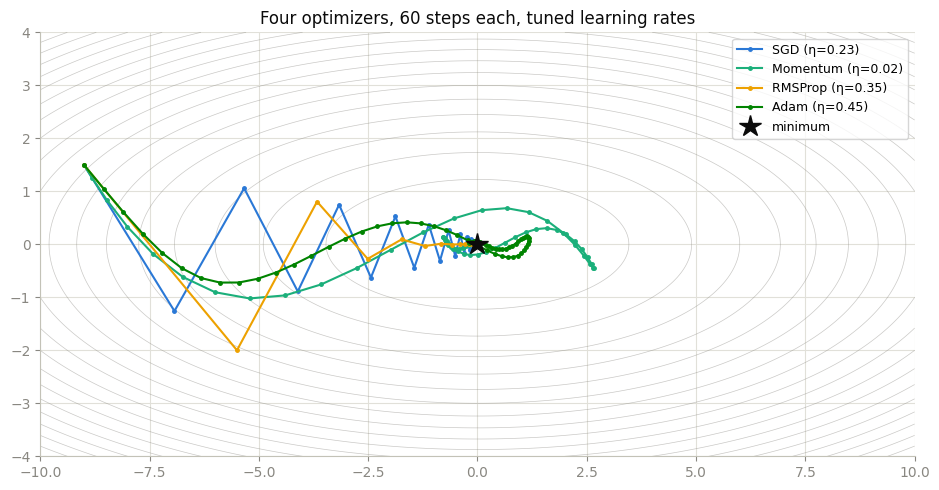

In [13]:
def run_optimizer(kind, lr, steps=60, w0=(-9.0, 1.5)):
    w = np.array(w0); path = [w.copy()]
    v = np.zeros(2); s = np.zeros(2)
    for t in range(1, steps+1):
        g = grad_f(w)
        if kind == "sgd":
            w = w - lr*g
        elif kind == "momentum":
            v = 0.9*v + g
            w = w - lr*v
        elif kind == "rmsprop":
            s = 0.99*s + 0.01*g**2
            w = w - lr * g/(np.sqrt(s)+1e-8)
        elif kind == "adam":
            v = 0.9*v + 0.1*g
            s = 0.999*s + 0.001*g**2
            vh, sh = v/(1-0.9**t), s/(1-0.999**t)      # bias correction
            w = w - lr * vh/(np.sqrt(sh)+1e-8)
        path.append(w.copy())
    return np.array(path)

runs = [("sgd", 0.23, "SGD"), ("momentum", 0.02, "Momentum"),
        ("rmsprop", 0.35, "RMSProp"), ("adam", 0.45, "Adam")]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.contour(xx_ := np.linspace(-10, 10, 200)[None,:]*np.ones((200,1)),
           yy_ := np.linspace(-4, 4, 200)[:,None]*np.ones((1,200)),
           0.5*(A[0]*xx_**2 + A[1]*yy_**2), levels=18, colors=[GRAY], linewidths=.5, alpha=.45)
for i, (kind, lr, label) in enumerate(runs):
    p = run_optimizer(kind, lr)
    ax.plot(*p.T, marker="o", ms=2.5, lw=1.5, color=PALETTE[i], label=f"{label} (η={lr})")
ax.plot(0, 0, marker="*", ms=16, color="#0b0b0b", ls="none", label="minimum")
ax.set_title("Four optimizers, 60 steps each, tuned learning rates")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()

SGD (blue) zigzags; momentum (green) smooths the zigzag and overshoots a little like a
heavy ball; RMSProp (yellow) and Adam (dark green) rescale per-coordinate and cut almost
straight to the minimum. **Practical rule:** start with Adam/AdamW at `lr=1e-3` (or `3e-4`);
switch to SGD+momentum only when squeezing the last % on vision tasks.

<a id="10"></a>
## 10. Autograd: how frameworks compute gradients

Writing `backward()` by hand (§7) doesn't scale to arbitrary architectures. Frameworks
instead record every operation into a **computation graph** while the forward pass runs, and
then replay it backwards applying the chain rule — **reverse-mode automatic differentiation**.
The core is astonishingly small; here is a working engine in ~35 lines (a miniature of
Karpathy's *micrograd* — and conceptually, of PyTorch itself):

In [14]:
class Value:
    '''A scalar that remembers how it was computed, so it can backpropagate.'''
    def __init__(self, data, parents=(), backward_fn=None):
        self.data, self.grad = data, 0.0
        self._parents, self._backward = parents, backward_fn or (lambda: None)

    def __add__(self, o):
        o = o if isinstance(o, Value) else Value(o)
        out = Value(self.data + o.data, (self, o))
        def back():  self.grad += out.grad;  o.grad += out.grad
        out._backward = back; return out

    def __mul__(self, o):
        o = o if isinstance(o, Value) else Value(o)
        out = Value(self.data * o.data, (self, o))
        def back():  self.grad += o.data*out.grad;  o.grad += self.data*out.grad
        out._backward = back; return out

    def tanh(self):
        t = np.tanh(self.data); out = Value(t, (self,))
        def back():  self.grad += (1 - t**2) * out.grad
        out._backward = back; return out

    def backward(self):
        order, seen = [], set()                     # topological sort of the graph
        def visit(v):
            if v not in seen:
                seen.add(v)
                for p in v._parents: visit(p)
                order.append(v)
        visit(self)
        self.grad = 1.0
        for v in reversed(order): v._backward()

# A tiny neuron: y = tanh(w1*x1 + w2*x2 + b), gradients by our engine...
x1, x2 = Value(0.5), Value(-1.2)
w1, w2, b = Value(0.8), Value(-0.4), Value(0.1)
y = (w1*x1 + w2*x2 + b).tanh()
y.backward()
print(f"micro-engine : y={y.data:.5f}  dw1={w1.grad:.5f}  dw2={w2.grad:.5f}  db={b.grad:.5f}")

# ...checked against PyTorch's autograd on the identical expression
tw1, tw2, tb = (torch.tensor(v, requires_grad=True) for v in (0.8, -0.4, 0.1))
ty = torch.tanh(tw1*0.5 + tw2*(-1.2) + tb)
ty.backward()
print(f"torch autograd: y={ty.item():.5f}  dw1={tw1.grad:.5f}  dw2={tw2.grad:.5f}  db={tb.grad:.5f}")

micro-engine : y=0.75307  dw1=0.21645  dw2=-0.51947  db=0.43289
torch autograd: y=0.75307  dw1=0.21645  dw2=-0.51947  db=0.43289


Identical numbers. Every `Value` op stores *how to push gradient to its parents*;
`backward()` walks the graph once in reverse. PyTorch does exactly this with tensors instead
of scalars, hundreds of ops instead of three, and C++/CUDA kernels — but the idea fits in one
screen. From here on we let PyTorch do the bookkeeping.

<a id="11"></a>
## 11. The PyTorch training loop

Time to graduate from NumPy. Every PyTorch project — from this notebook to GPT — is the same
five-line loop:

```python
for xb, yb in loader:
    loss = criterion(model(xb), yb)   # forward
    optimizer.zero_grad()             # clear old gradients
    loss.backward()                   # backprop (the autograd of §10)
    optimizer.step()                  # update weights
```

Our workhorse dataset for the rest of the notebook: scikit-learn **digits** — 1,797
hand-written digits as 8×8 grayscale images. Small enough to train anything in seconds on CPU,
real enough to be interesting.

train (1347, 64) | test (450, 64) | 10 classes


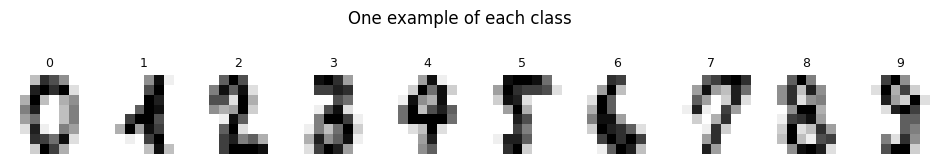

In [15]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

digits = load_digits()
X_all = (digits.data / 16.0).astype(np.float32)         # pixels 0..16 → 0..1
y_all = digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25,
                                          stratify=y_all, random_state=0)
print(f"train {X_tr.shape} | test {X_te.shape} | {len(np.unique(y_all))} classes")

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for ax, i in zip(axes, range(10)):
    ax.imshow(X_tr[y_tr == i][0].reshape(8, 8), cmap="gray_r")
    ax.set_title(y_tr[y_tr == i][0], fontsize=9); ax.axis("off")
plt.suptitle("One example of each class", y=1.15)
plt.show()

# Tensors + loaders used throughout Parts III–VI
Xtr_t, ytr_t = torch.tensor(X_tr), torch.tensor(y_tr)
Xte_t, yte_t = torch.tensor(X_te), torch.tensor(y_te)
train_dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=64, shuffle=True)

test accuracy after 30 epochs: 0.9578


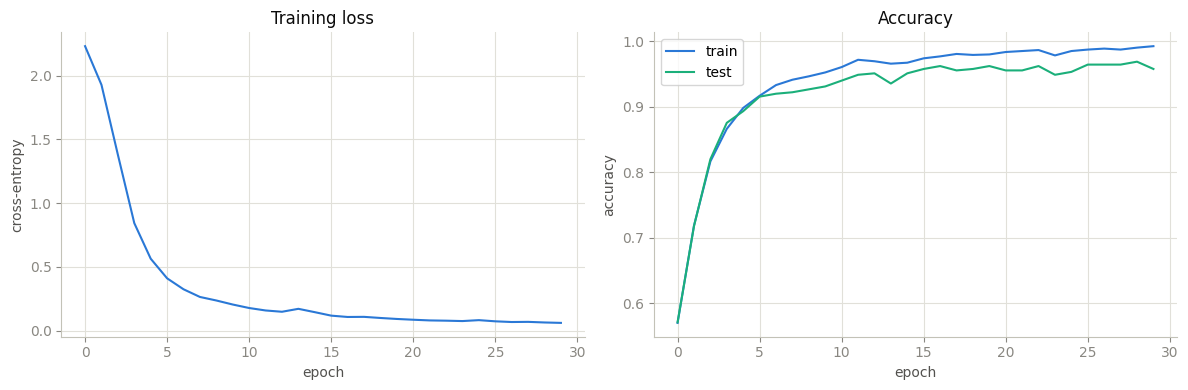

In [16]:
class MLP(nn.Module):
    def __init__(self, sizes=(64, 128, 64, 10), p_drop=0.0):
        super().__init__()
        layers = []
        for a, b in zip(sizes[:-2], sizes[1:-1]):
            layers += [nn.Linear(a, b), nn.ReLU(), nn.Dropout(p_drop)]
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

@torch.no_grad()
def accuracy(model, X, y):
    model.eval()
    return (model(X).argmax(1) == y).float().mean().item()

def train_classifier(model, loader, X_val, y_val, epochs=30, lr=1e-3,
                     weight_decay=0.0, optimizer=None, scheduler=None):
    opt = optimizer or torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {"train_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train(); running = 0.0
        for xb, yb in loader:
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            if scheduler is not None: scheduler.step()
            running += loss.item() * len(xb)
        hist["train_loss"].append(running / len(loader.dataset))
        hist["train_acc"].append(accuracy(model, loader.dataset.tensors[0],
                                          loader.dataset.tensors[1]))
        hist["val_acc"].append(accuracy(model, X_val, y_val))
    return hist

torch.manual_seed(0)
mlp = MLP()
hist = train_classifier(mlp, train_dl, Xte_t, yte_t, epochs=30)
mlp_test_acc = hist["val_acc"][-1]
print(f"test accuracy after 30 epochs: {mlp_test_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist["train_loss"], color=PALETTE[0])
ax1.set_xlabel("epoch"); ax1.set_ylabel("cross-entropy"); ax1.set_title("Training loss")
ax2.plot(hist["train_acc"], label="train"); ax2.plot(hist["val_acc"], label="test")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout()

~97–98% in seconds. Note the pattern we will reuse all notebook: `model.train()` /
`model.eval()` (matters once dropout & batch-norm appear), loss on raw logits via
`F.cross_entropy`, evaluation under `torch.no_grad()`. The train/test gap you can see is
generalization error — Part III is about controlling it.

<a id="12"></a>
## 12. Weight initialization and vanishing/exploding signals

A deep network is a chain of multiplications, so anything slightly off compounds
exponentially with depth. Initialize weights too small → the signal (and its gradient)
**vanishes**; too large → activations **saturate or explode**. The fix is to choose the
initial scale so each layer preserves variance:

- **Xavier/Glorot** (tanh, sigmoid): $\mathrm{Var}(W) = 1/n_{\text{in}}$
- **He/Kaiming** (ReLU — which zeroes half its inputs): $\mathrm{Var}(W) = 2/n_{\text{in}}$

Watch the activation scale flow through 30 layers under each choice:

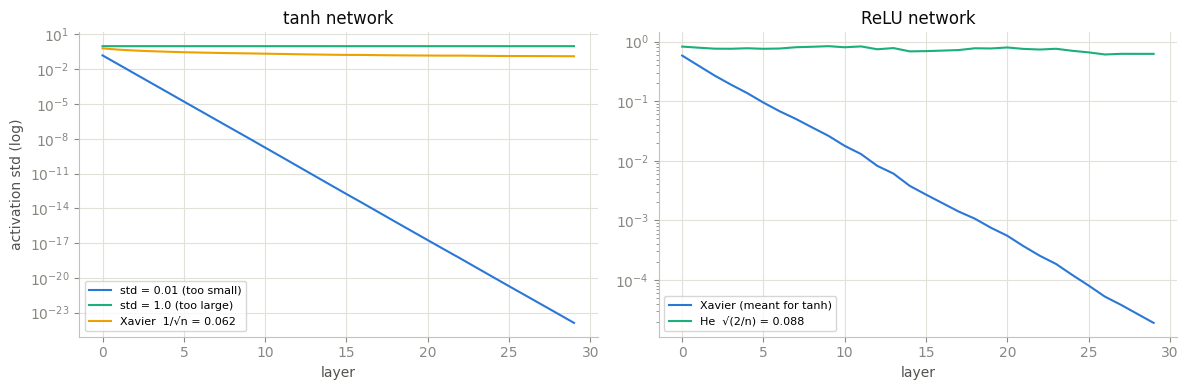

In [17]:
def signal_through_depth(w_std, act, depth=30, width=256, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(512, width, generator=g)
    stds = []
    for _ in range(depth):
        W = torch.randn(width, width, generator=g) * w_std
        x = act(x @ W)
        stds.append(x.std().item())
    return stds

depth, width = 30, 256
xavier, he = (1/width)**.5, (2/width)**.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for std, label in [(0.01, "std = 0.01 (too small)"), (1.0, "std = 1.0 (too large)"),
                   (xavier, f"Xavier  1/√n = {xavier:.3f}")]:
    ax1.plot(signal_through_depth(std, torch.tanh), label=label)
ax1.set_yscale("log"); ax1.set_xlabel("layer"); ax1.set_ylabel("activation std (log)")
ax1.set_title("tanh network"); ax1.legend(fontsize=8)

for std, label in [(xavier, "Xavier (meant for tanh)"), (he, f"He  √(2/n) = {he:.3f}")]:
    ax2.plot(signal_through_depth(std, torch.relu), label=label)
ax2.set_yscale("log"); ax2.set_xlabel("layer")
ax2.set_title("ReLU network"); ax2.legend(fontsize=8)
plt.tight_layout()

Left: too-small init decays the signal to ~$10^{-30}$ (nothing to learn from); too-large
saturates tanh (std pins near 1.0 but every unit sits at ±1 where the gradient is ~0);
Xavier holds steady. Right: Xavier under ReLU still halves the variance every layer — He's
extra factor of 2 fixes exactly that. Since backprop runs through the same weights, healthy
activations ⇒ healthy gradients. PyTorch's defaults (Kaiming-uniform for `nn.Linear`/`nn.Conv2d`)
do this for you — but you now know *why*, and you'll recognize the failure signature.

<a id="13"></a>
## 13. Regularization: weight decay, dropout, early stopping

A big network can memorize a small training set perfectly and still fail on new data —
**overfitting**. The three standard controls:

- **Weight decay (L2)** — add $\lambda\|\theta\|^2$ to the loss; prefers many small weights
  over a few huge ones (use `AdamW`, which decouples decay from the Adam update)
- **Dropout** — during training, randomly zero each hidden unit with probability $p$;
  no unit can rely on any other, so the net learns redundant, robust features
- **Early stopping** — track validation accuracy and keep the best checkpoint; simplest and
  arguably most used regularizer in existence

To *see* overfitting we make it easy: train an oversized MLP on only **150 examples**.

plain:       best val acc 0.911 (epoch 63), final 0.904
regularized: best val acc 0.924, final 0.924


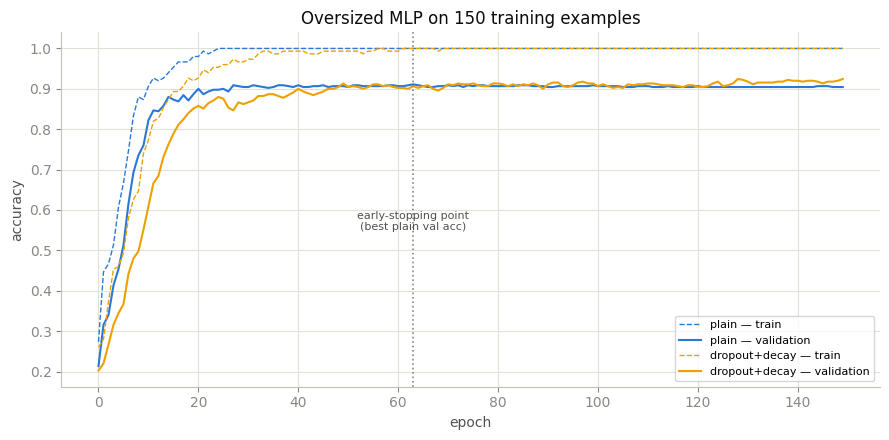

In [18]:
idx_small = rng.choice(len(X_tr), 150, replace=False)
small_dl = DataLoader(TensorDataset(Xtr_t[idx_small], ytr_t[idx_small]),
                      batch_size=32, shuffle=True)

torch.manual_seed(1)
plain = MLP((64, 256, 128, 10))
hist_plain = train_classifier(plain, small_dl, Xte_t, yte_t, epochs=150)

torch.manual_seed(1)
reg = MLP((64, 256, 128, 10), p_drop=0.5)
opt = torch.optim.AdamW(reg.parameters(), lr=1e-3, weight_decay=1e-2)
hist_reg = train_classifier(reg, small_dl, Xte_t, yte_t, epochs=150, optimizer=opt)

best_ep = int(np.argmax(hist_plain["val_acc"]))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_plain["train_acc"], color=PALETTE[0], ls="--", lw=1, label="plain — train")
ax.plot(hist_plain["val_acc"],   color=PALETTE[0], label="plain — validation")
ax.plot(hist_reg["train_acc"],   color=PALETTE[2], ls="--", lw=1, label="dropout+decay — train")
ax.plot(hist_reg["val_acc"],     color=PALETTE[2], label="dropout+decay — validation")
ax.axvline(best_ep, color=GRAY, ls=":", lw=1.2)
ax.annotate("early-stopping point\n(best plain val acc)", xy=(best_ep, .55),
            fontsize=8, color="#52514e", ha="center")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
ax.set_title("Oversized MLP on 150 training examples"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
print(f"plain:       best val acc {max(hist_plain['val_acc']):.3f} (epoch {best_ep}), "
      f"final {hist_plain['val_acc'][-1]:.3f}")
print(f"regularized: best val acc {max(hist_reg['val_acc']):.3f}, "
      f"final {hist_reg['val_acc'][-1]:.3f}")

The plain model hits 100% train accuracy (memorization) while its validation curve stalls
or sags — the growing gap *is* overfitting. The regularized model trains slower, never fully
memorizes, and holds a better validation score. In practice you combine all three: modest
weight decay + dropout on the biggest layers + early stopping on the validation metric.

<a id="14"></a>
## 14. Batch normalization

As training updates every layer at once, each layer's input distribution keeps shifting under
it. **BatchNorm** re-standardizes each unit over the mini-batch — $\hat x = (x-\mu_B)/\sigma_B$
— then lets the network re-scale with two learned parameters $\gamma, \beta$. Effects:
gradients stay healthy in deep stacks, much larger learning rates become usable, and there's a
mild regularization bonus from batch noise. (At eval time it uses running averages —
another reason `model.eval()` matters.)

The cruelest test: a 6-hidden-layer **sigmoid** network — a depth/activation combo that
barely trains at all without normalization.

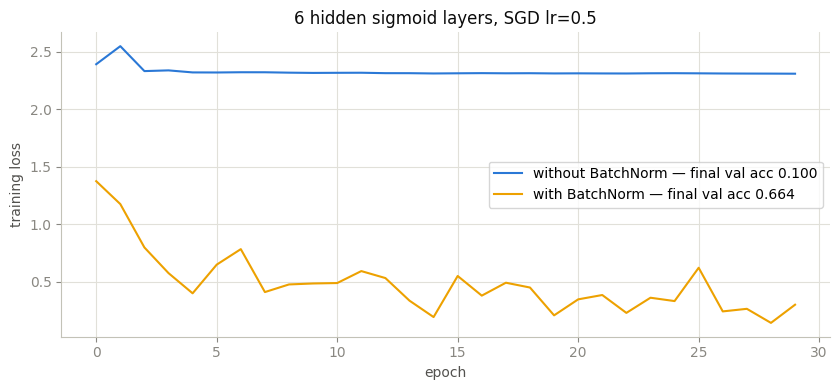

In [19]:
def deep_sigmoid_net(use_bn):
    layers, w = [], [64] + [96]*6
    for a, b in zip(w[:-1], w[1:]):
        layers.append(nn.Linear(a, b))
        if use_bn: layers.append(nn.BatchNorm1d(b))
        layers.append(nn.Sigmoid())
    layers.append(nn.Linear(w[-1], 10))
    return nn.Sequential(*layers)

fig, ax = plt.subplots(figsize=(8.5, 4))
for use_bn, label, c in [(False, "without BatchNorm", PALETTE[0]),
                         (True,  "with BatchNorm",    PALETTE[2])]:
    torch.manual_seed(0)
    model = deep_sigmoid_net(use_bn)
    opt = torch.optim.SGD(model.parameters(), lr=0.5)
    h = train_classifier(model, train_dl, Xte_t, yte_t, epochs=30, optimizer=opt)
    ax.plot(h["train_loss"], color=c, label=f"{label} — final val acc {h['val_acc'][-1]:.3f}")
ax.set_xlabel("epoch"); ax.set_ylabel("training loss")
ax.set_title("6 hidden sigmoid layers, SGD lr=0.5"); ax.legend()
plt.tight_layout()

Without BN the deep sigmoid stack is nearly untrainable (vanishing gradients, §12 in
action); with BN it just… trains. Modern practice: **BatchNorm after conv layers** in CNNs,
**LayerNorm** (per-example, batch-independent — §21) in Transformers and RNNs.

<a id="15"></a>
## 15. Learning-rate schedules

One constant learning rate is rarely optimal end-to-end: early training wants big steps,
convergence wants small ones. Schedulers decay η over time — and **warmup** (starting tiny
for a few hundred steps) protects the fragile early phase. The shapes you'll meet:

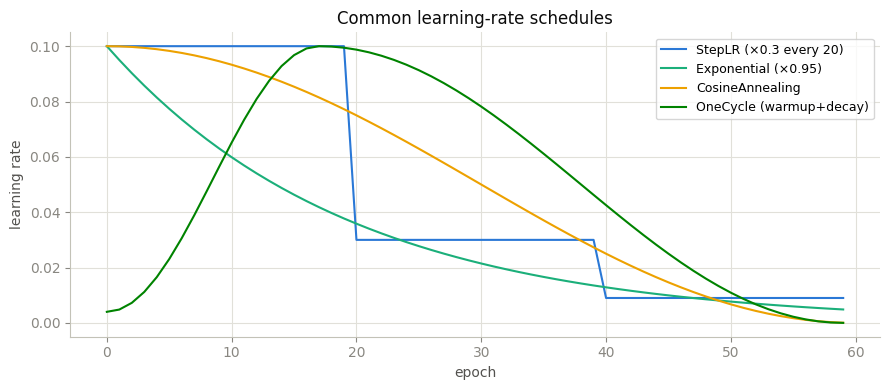

In [20]:
epochs = 60
schedules = {
    "StepLR (×0.3 every 20)": lambda o: torch.optim.lr_scheduler.StepLR(o, 20, gamma=0.3),
    "Exponential (×0.95)":    lambda o: torch.optim.lr_scheduler.ExponentialLR(o, gamma=0.95),
    "CosineAnnealing":        lambda o: torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=epochs),
    "OneCycle (warmup+decay)": lambda o: torch.optim.lr_scheduler.OneCycleLR(o, max_lr=0.1,
                                                                             total_steps=epochs),
}
import warnings
fig, ax = plt.subplots(figsize=(9, 4))
for i, (name, make_sched) in enumerate(schedules.items()):
    opt = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=0.1)
    sch = make_sched(opt)
    lrs = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # we step the scheduler alone just to read its lr
        for _ in range(epochs):
            lrs.append(opt.param_groups[0]["lr"]); sch.step()
    ax.plot(lrs, color=PALETTE[i], label=name)
ax.set_xlabel("epoch"); ax.set_ylabel("learning rate")
ax.set_title("Common learning-rate schedules"); ax.legend(fontsize=9)
plt.tight_layout()

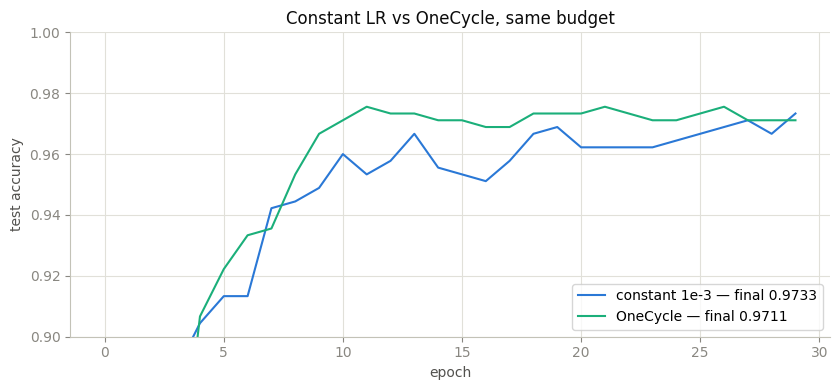

In [21]:
# Does it matter? Same MLP, 30 epochs: constant lr vs OneCycle.
results = {}
for name in ["constant 1e-3", "OneCycle"]:
    torch.manual_seed(2)
    m = MLP()
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
    sch = None
    if name == "OneCycle":
        sch = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=5e-3,
                                                  total_steps=30*len(train_dl))
    results[name] = train_classifier(m, train_dl, Xte_t, yte_t, epochs=30,
                                     optimizer=opt, scheduler=sch)

fig, ax = plt.subplots(figsize=(8.5, 4))
for i, (name, h) in enumerate(results.items()):
    ax.plot(h["val_acc"], color=PALETTE[i], label=f"{name} — final {h['val_acc'][-1]:.4f}")
ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy"); ax.set_ylim(.9, 1.0)
ax.set_title("Constant LR vs OneCycle, same budget"); ax.legend(loc="lower right")
plt.tight_layout()

OneCycle briefly *hurts* mid-training (its peak lr is 5× higher — that's the exploration
phase) and then anneals into a slightly better, more stable final score. On harder problems
the gap is larger. Default recipe today: **AdamW + warmup + cosine/OneCycle decay** — it's
what most modern vision models and LLMs train with.

<a id="16"></a>
## 16. Convolutional networks

An MLP on images is wasteful: it has no idea pixel (3,4) neighbors pixel (3,5), and it learns
a separate weight for every pixel position. A **convolution** fixes both — slide one small
$k\times k$ kernel across the image:

- **Local connectivity** — each output looks at a small patch
- **Weight sharing** — the *same* kernel is used at every position, so a feature detector
  learned in one corner works everywhere
- Followed by **pooling** (downsampling), stacking conv blocks builds the edge → shape →
  object hierarchy from §1

First, convolution itself, by hand in NumPy — the kernels here are hand-set edge detectors,
exactly the kind a trained CNN discovers on its own:

dense layer 64→64: 4096 weights | conv layer 1→8 channels of 3×3: 80 weights — weight sharing is a ~51× saving


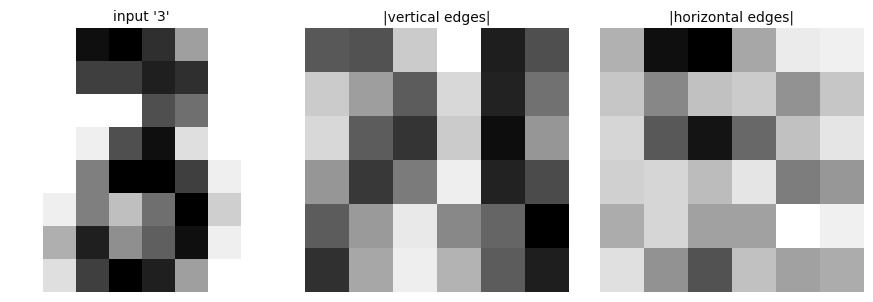

In [22]:
def conv2d_naive(img, kernel):
    kh, kw = kernel.shape
    H, W = img.shape
    out = np.zeros((H-kh+1, W-kw+1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = (img[i:i+kh, j:j+kw] * kernel).sum()   # dot product per patch
    return out

img = X_tr[y_tr == 3][0].reshape(8, 8)
k_vert = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])       # Sobel: vertical edges
k_horz = k_vert.T                                             # horizontal edges

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (im, t) in zip(axes, [(img, "input '3'"),
                              (np.abs(conv2d_naive(img, k_vert)), "|vertical edges|"),
                              (np.abs(conv2d_naive(img, k_horz)), "|horizontal edges|")]):
    ax.imshow(im, cmap="gray_r"); ax.set_title(t, fontsize=10); ax.axis("off")
plt.tight_layout()

dense_params = 64 * 64
conv_params  = 8 * (3*3*1) + 8
print(f"dense layer 64→64: {dense_params} weights | conv layer 1→8 channels of 3×3: "
      f"{conv_params} weights — weight sharing is a ~{dense_params//conv_params}× saving")

In [23]:
class CNN(nn.Module):
    def __init__(self, n_out=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),     # 8×8 → 8 maps of 8×8
            nn.MaxPool2d(2),                              # → 8 maps of 4×4
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),    # → 16 maps of 4×4
            nn.MaxPool2d(2),                              # → 16 maps of 2×2
        )
        self.head = nn.Linear(16*2*2, n_out)
    def forward(self, x):
        return self.head(self.features(x).flatten(1))

Xtr_img = Xtr_t.reshape(-1, 1, 8, 8); Xte_img = Xte_t.reshape(-1, 1, 8, 8)
train_img_dl = DataLoader(TensorDataset(Xtr_img, ytr_t), batch_size=64, shuffle=True)

torch.manual_seed(0)
cnn = CNN()
hist_cnn = train_classifier(cnn, train_img_dl, Xte_img, yte_t, epochs=30)
n_cnn = sum(p.numel() for p in cnn.parameters())
n_mlp = sum(p.numel() for p in mlp.parameters())
print(f"CNN  test acc {hist_cnn['val_acc'][-1]:.4f}  ({n_cnn:,} params)")
print(f"MLP  test acc {mlp_test_acc:.4f}  ({n_mlp:,} params)")

CNN  test acc 0.9556  (1,898 params)
MLP  test acc 0.9578  (17,226 params)


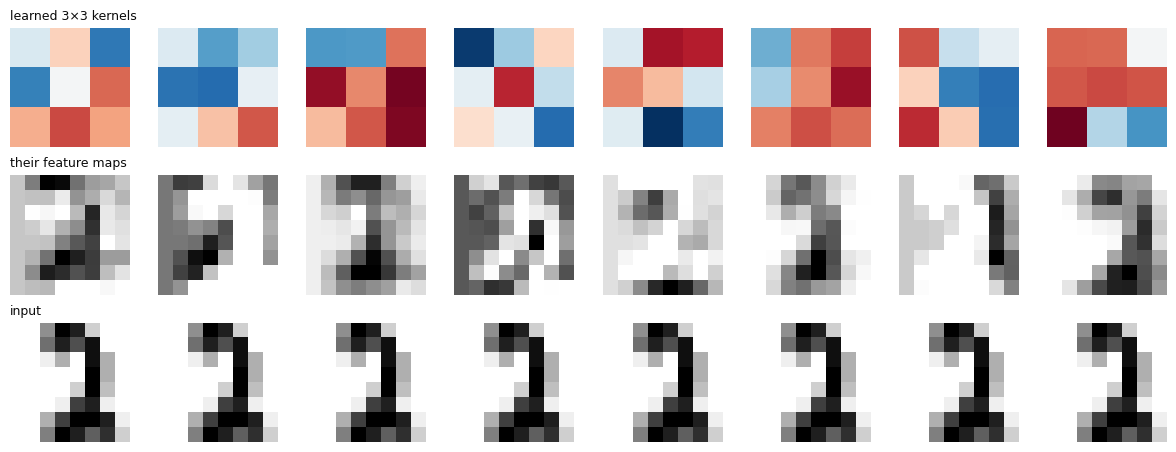

In [24]:
# What did it learn? First-layer kernels + their response maps for one input digit.
with torch.no_grad():
    filters = cnn.features[0].weight.squeeze(1).numpy()     # (8, 3, 3)
    fmaps = F.relu(cnn.features[0](Xte_img[:1]))[0].numpy() # (8, 8, 8)

fig, axes = plt.subplots(3, 8, figsize=(12, 4.6))
vmax = float(np.abs(filters).max())
for j in range(8):
    axes[0, j].imshow(filters[j], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[1, j].imshow(fmaps[j], cmap="gray_r")
    axes[2, j].imshow(Xte_img[0, 0], cmap="gray_r")
    for r in range(3): axes[r, j].axis("off")
axes[0, 0].set_title("learned 3×3 kernels", loc="left", fontsize=9)
axes[1, 0].set_title("their feature maps", loc="left", fontsize=9)
axes[2, 0].set_title("input", loc="left", fontsize=9)
plt.tight_layout()

Each learned kernel (top row, red = positive / blue = negative weights) responds to a
different local pattern — compare the feature maps (middle) with the hand-made Sobel results
above. Nobody told the network to build edge detectors; the loss did.

On accuracy the CNN merely *ties* the MLP — these 8×8 images are so tiny that a dense net is
already near the ceiling — but it does so with **9× fewer parameters**, and §28's conv net
with normalization will pull clearly ahead. On real images (224×224, where a dense first
layer would need ~150K weights *per unit*) the CNN's advantage becomes decisive. Scale this
recipe up (more channels, more blocks, residual connections) and you get ResNet — the same
three ideas, deeper.

<a id="17"></a>
## 17. Recurrent networks: learning from sequences

Sequences (text, audio, sensor streams) have variable length and order. An **RNN** processes
one step at a time, carrying a **hidden state** — a learned summary of everything seen so far:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

The same weights are reused at every time step (weight sharing again — convolution over
*time*). We'll train one to continue a noisy sine wave: it sees 40 past values and predicts
the next; chaining predictions lets it free-run into the future.

final training MSE: 0.00360


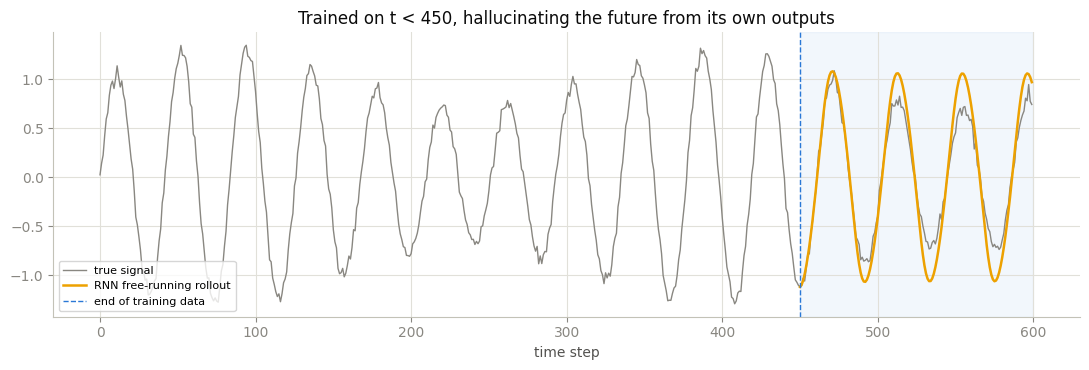

In [25]:
t_axis = np.arange(600)
wave = np.sin(0.15 * t_axis) * (1 + 0.3*np.sin(0.02*t_axis)) + rng.normal(0, .04, 600)
wave = wave.astype(np.float32)

WIN, SPLIT = 40, 450
X_seq = np.stack([wave[i:i+WIN] for i in range(SPLIT-WIN)])[..., None]  # (N, 40, 1)
y_seq = wave[WIN:SPLIT, None]

class SeqRNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.rnn = nn.RNN(1, hidden, batch_first=True)
        self.out = nn.Linear(hidden, 1)
    def forward(self, x):
        h_all, _ = self.rnn(x)          # hidden state at every step
        return self.out(h_all[:, -1])   # predict from the last one

torch.manual_seed(0)
srnn = SeqRNN()
opt = torch.optim.Adam(srnn.parameters(), lr=3e-3)
Xs_t, ys_t = torch.tensor(X_seq), torch.tensor(y_seq)
for ep in range(120):
    loss = F.mse_loss(srnn(Xs_t), ys_t)
    opt.zero_grad(); loss.backward(); opt.step()
print(f"final training MSE: {loss.item():.5f}")

# Free-running rollout: feed the model's own predictions back in
srnn.eval()
ctx = list(wave[SPLIT-WIN:SPLIT])
preds = []
with torch.no_grad():
    for _ in range(150):
        nxt = srnn(torch.tensor(np.array(ctx[-WIN:], dtype=np.float32))[None, :, None]).item()
        preds.append(nxt); ctx.append(nxt)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(t_axis, wave, color=GRAY, lw=1, label="true signal")
ax.plot(np.arange(SPLIT, SPLIT+150), preds, color=PALETTE[2], lw=1.8,
        label="RNN free-running rollout")
ax.axvspan(SPLIT, 600, color=PALETTE[0], alpha=.06)
ax.axvline(SPLIT, color=PALETTE[0], ls="--", lw=1, label="end of training data")
ax.set_xlabel("time step"); ax.legend(loc="lower left", fontsize=8)
ax.set_title("Trained on t < 450, hallucinating the future from its own outputs")
plt.tight_layout()

Right of the dashed line the model has **no input at all** — every value is its own
previous output. It has internalized the frequency and the slow amplitude envelope. This
closed-loop generation trick is the same one language models use, one token instead of one
sample at a time.

<a id="18"></a>
## 18. LSTMs and gating: the vanishing gradient, again

Backprop through an RNN multiplies by $W_h^\top \text{diag}(\tanh')$ once **per time step** —
§12's vanishing-signal problem, now over time: information from 50 steps ago is
exponentially hard to learn from. The **LSTM** (1997) adds a *cell state* — a conveyor belt
that flows through time with only element-wise gates touching it:

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t$$

The **forget gate** $f_t$ is *learned*: when it sits near 1, gradients ride the conveyor belt
across long spans instead of dying. Two experiments — gradient flow, then an actual
long-memory task:

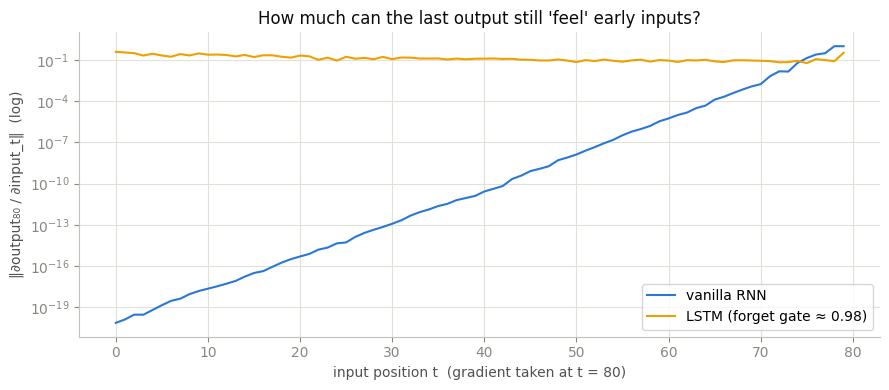

In [26]:
def grad_vs_distance(cell, T=80, insize=8):
    torch.manual_seed(3)
    x = torch.randn(1, T, insize, requires_grad=True)
    h_all, _ = cell(x)
    h_all[0, -1].sum().backward()                    # gradient of the LAST output...
    return x.grad[0].norm(dim=1).numpy()             # ...w.r.t. the input at EVERY step

rnn_cell  = nn.RNN(8, 32, batch_first=True)
lstm_cell = nn.LSTM(8, 32, batch_first=True)
with torch.no_grad():                                # encourage remembering: forget gate ≈ 0.98
    for name, p in lstm_cell.named_parameters():
        if "bias" in name: p[32:64] = 2.0            # bias slice [h:2h] is the forget gate

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grad_vs_distance(rnn_cell),  color=PALETTE[0], label="vanilla RNN")
ax.plot(grad_vs_distance(lstm_cell), color=PALETTE[2], label="LSTM (forget gate ≈ 0.98)")
ax.set_yscale("log"); ax.set_xlabel("input position t  (gradient taken at t = 80)")
ax.set_ylabel("‖∂output₈₀ / ∂input_t‖  (log)")
ax.set_title("How much can the last output still 'feel' early inputs?")
ax.legend()
plt.tight_layout()

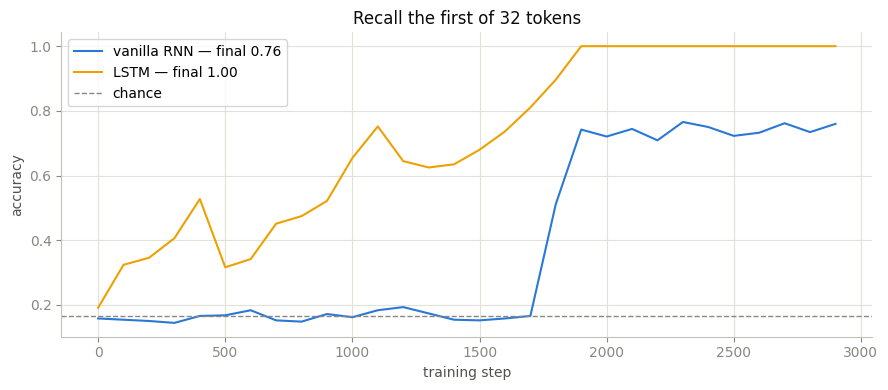

In [27]:
# The task: read 32 random tokens, then report the FIRST one. Pure long-range memory.
V, T = 6, 32
def echo_batch(n=64):
    x = torch.randint(0, V, (n, T))
    return F.one_hot(x, V).float(), x[:, 0]

class Recaller(nn.Module):
    def __init__(self, cell_cls):
        super().__init__()
        self.cell = cell_cls(V, 64, batch_first=True)
        if cell_cls is nn.LSTM:
            with torch.no_grad():                # start the forget gates open (≈0.88)
                for name, p in self.cell.named_parameters():
                    if "bias" in name: p[64:128] = 1.0
        self.out = nn.Linear(64, V)
    def forward(self, x):
        h_all, _ = self.cell(x)
        return self.out(h_all[:, -1])

fig, ax = plt.subplots(figsize=(9, 4))
for cell_cls, label, c in [(nn.RNN, "vanilla RNN", PALETTE[0]), (nn.LSTM, "LSTM", PALETTE[2])]:
    torch.manual_seed(0)
    model = Recaller(cell_cls)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    accs = []
    for step in range(3000):
        xb, yb = echo_batch()
        loss = F.cross_entropy(model(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 100 == 0:
            with torch.no_grad():
                xv, yv = echo_batch(512)
                accs.append((model(xv).argmax(1) == yv).float().mean().item())
    ax.plot(np.arange(len(accs))*100, accs, color=c,
            label=f"{label} — final {accs[-1]:.2f}")
ax.axhline(1/V, color=GRAY, ls="--", lw=1, label="chance")
ax.set_xlabel("training step"); ax.set_ylabel("accuracy")
ax.set_title("Recall the first of 32 tokens"); ax.legend()
plt.tight_layout()

The RNN's gradient signal decays ~10 orders of magnitude across 80 steps; the LSTM's
conveyor belt keeps it alive — and on the recall task the LSTM snaps to ~100% while the
vanilla RNN spends thousands of steps clawing part-way there (push T higher and it fails
completely). **GRUs** are a cheaper 2-gate variant of the same idea. (Foreshadowing: §20's
attention solves long range even more directly — skip the belt, just *look back*.)

<a id="19"></a>
## 19. Embeddings: turning symbols into geometry

Networks eat numbers, not symbols. One-hot vectors work but say every pair of symbols is
equally different. An **embedding** instead gives each symbol a learned dense vector
(`nn.Embedding` = a trainable lookup table). Trained on *predict the next character*,
vectors of characters that behave alike drift together — meaning emerges from usage. This is
word2vec's insight and layer 0 of every language model.

In [28]:
corpus = ("deep learning is the study of neural networks with many layers . "
          "a network learns features from data instead of hand coded rules . "
          "gradient descent tunes the weights to reduce the loss . "
          "the hidden layers learn simple edges then shapes then whole objects . "
          "training needs data , a loss , and an optimizer . "
          "recurrent networks read sequences and transformers use attention . ") * 3
chars = sorted(set(corpus))
stoi = {c: i for i, c in enumerate(chars)}
V_ch, CTX = len(chars), 5
enc = np.array([stoi[c] for c in corpus])
print(f"{len(corpus)} characters, vocab of {V_ch}: {''.join(chars)!r}")

class CharModel(nn.Module):
    def __init__(self, d=12):
        super().__init__()
        self.emb = nn.Embedding(V_ch, d)
        self.mlp = nn.Sequential(nn.Linear(CTX*d, 96), nn.ReLU(), nn.Linear(96, V_ch))
    def forward(self, idx):                       # idx: (B, CTX) integer tokens
        return self.mlp(self.emb(idx).flatten(1)) # look up vectors, concat, predict next

torch.manual_seed(0)
cm = CharModel()
opt = torch.optim.Adam(cm.parameters(), lr=3e-3)
pos = np.arange(len(enc) - CTX)
first_loss = None
for step in range(2500):
    b = rng.choice(pos, 128)
    xb = torch.tensor(np.stack([enc[i:i+CTX] for i in b]))
    yb = torch.tensor(enc[b + CTX])
    loss = F.cross_entropy(cm(xb), yb)
    if first_loss is None: first_loss = loss.item()
    opt.zero_grad(); loss.backward(); opt.step()
print(f"loss {first_loss:.2f} → {loss.item():.2f}  "
      f"(uniform guessing would be log({V_ch}) = {np.log(V_ch):.2f})")

# Generate: same closed-loop trick as §17, greedy next-char
ctx = "the netw"
with torch.no_grad():
    for _ in range(60):
        x = torch.tensor([[stoi[c] for c in ctx[-CTX:]]])
        ctx += chars[cm(x).argmax(1).item()]
print("greedy sample:", repr(ctx))

1122 characters, vocab of 27: ' ,.abcdefghijklmnopqrstuwyz'


loss 3.36 → 0.05  (uniform guessing would be log(27) = 3.30)
greedy sample: 'the network learning is then whole objects . the hidden layers learn'


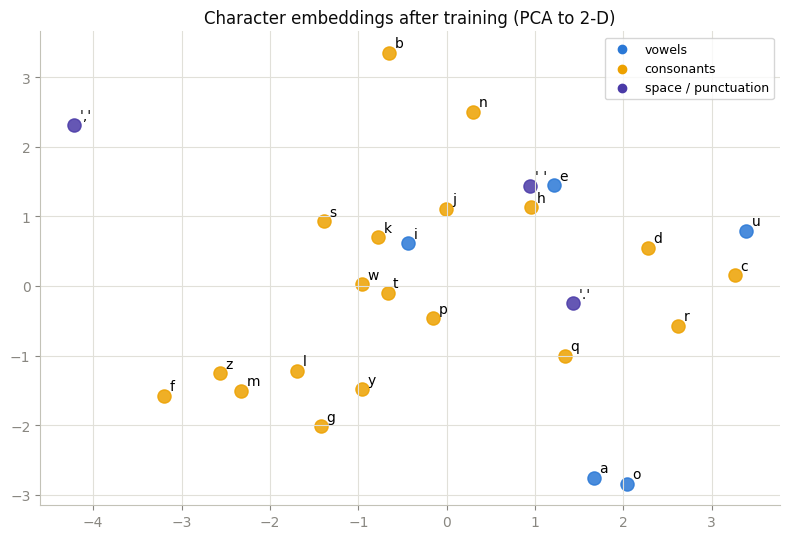

In [29]:
from sklearn.decomposition import PCA

E2 = PCA(n_components=2).fit_transform(cm.emb.weight.detach().numpy())
vowels = set("aeiou")
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, c in enumerate(chars):
    kind = 0 if c in vowels else (2 if c.isalpha() else 4)
    ax.scatter(*E2[i], s=90, color=PALETTE[kind], alpha=.85)
    ax.annotate(repr(c) if not c.isalpha() else c, E2[i], fontsize=10,
                xytext=(4, 4), textcoords="offset points")
for kind, label in [(0, "vowels"), (2, "consonants"), (4, "space / punctuation")]:
    ax.scatter([], [], color=PALETTE[kind], label=label)
ax.set_title("Character embeddings after training (PCA to 2-D)")
ax.legend(fontsize=9)
plt.tight_layout()

Nobody labeled these characters — any structure in the map was learned purely from *how
each character is used in context* (note `a`/`o` side by side, and space/punctuation pushed
away from the letters). Our corpus is only ~1 KB, so the layout is fuzzy; train the same model
on megabytes of text and the vowel/consonant clusters snap into place. Swap characters for
sub-word tokens and dimensions 12 → 4,096 and this is exactly the input layer of a modern
LLM.

<a id="20"></a>
## 20. Attention from scratch

RNNs squeeze the whole past into one fixed-size hidden state — a bottleneck. **Attention**
removes it: at every position, directly look at *all* other positions and take a weighted
average of what's relevant. Each token emits three vectors — a **query** ("what am I looking
for?"), a **key** ("what do I contain?"), and a **value** ("what do I offer?") — and:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Six lines of code, and it's the engine of every Transformer:

output per token: (6, 16) — same length as input, every position enriched


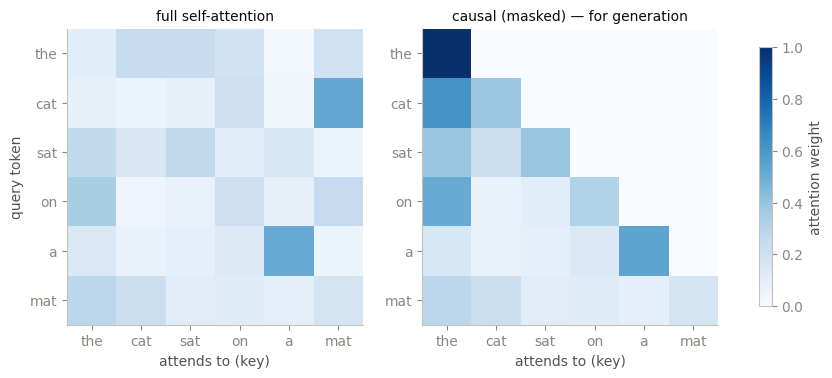

In [30]:
def attention(Q, K, V, causal=False):
    scores = Q @ K.transpose(-2, -1) / np.sqrt(Q.shape[-1])   # (T, T) similarity of Q·K
    if causal:                                                # hide the future:
        T = scores.shape[-1]
        scores = scores.masked_fill(torch.triu(torch.ones(T, T), 1).bool(), -torch.inf)
    W = torch.softmax(scores, dim=-1)                         # rows sum to 1
    return W @ V, W                                           # blend values by weight

tokens = ["the", "cat", "sat", "on", "a", "mat"]
torch.manual_seed(5)
E = torch.randn(len(tokens), 16)                              # stand-in embeddings
Wq, Wk, Wv = (torch.randn(16, 16)/4 for _ in range(3))        # per-token projections
out, W_full = attention(E @ Wq, E @ Wk, E @ Wv)
_,   W_caus = attention(E @ Wq, E @ Wk, E @ Wv, causal=True)
print("output per token:", tuple(out.shape), "— same length as input, every position enriched")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, W, title in [(axes[0], W_full, "full self-attention"),
                     (axes[1], W_caus, "causal (masked) — for generation")]:
    im = ax.imshow(W, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(6), tokens); ax.set_yticks(range(6), tokens)
    ax.set_xlabel("attends to (key)"); ax.set_title(title, fontsize=10); ax.grid(False)
axes[0].set_ylabel("query token")
fig.colorbar(im, ax=axes, shrink=.8, label="attention weight")
plt.show()

Each **row** is one token's attention budget (rows sum to 1). The causal mask zeroes the
upper triangle so a token can only look left — mandatory when generating text one token at a
time, since the future doesn't exist yet. These weights are random (untrained projections);
next section a real trained network puts its attention *exactly* where the task demands.

<a id="21"></a>
## 21. A tiny Transformer

A **Transformer** is attention (§20) made into a full architecture. One block =

1. **Multi-head** self-attention — run $h$ attentions in parallel on $d/h$-dim slices, so
   different heads can track different relationships
2. **Position embeddings** — attention is order-blind, so add a learned vector per position
3. **Residual connections + LayerNorm** — `x = x + sublayer(norm(x))`, the gradient highway
   that makes 100-layer stacks trainable
4. A position-wise **feed-forward** MLP

We build all of it from scratch (~40 lines) and train it on a task with a beautifully
*visible* solution: **output the input sequence reversed**. To reverse, position $i$ must
attend to position $T{-}1{-}i$ — so a trained attention map should show an anti-diagonal
stripe. Let's check.

In [31]:
V_tok, T_seq, D, HEADS = 10, 10, 32, 2

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        self.h = n_heads
        self.qkv  = nn.Linear(d, 3*d)     # one matmul makes Q, K, V for all heads
        self.proj = nn.Linear(d, d)
    def forward(self, x):
        B, T, D = x.shape
        q, k, v = (self.qkv(x).reshape(B, T, 3, self.h, D//self.h)
                       .permute(2, 0, 3, 1, 4))          # each: (B, heads, T, D/heads)
        att = torch.softmax(q @ k.transpose(-2, -1) / np.sqrt(D//self.h), dim=-1)
        self.last_attn = att.detach()                    # stash for visualization
        return self.proj((att @ v).transpose(1, 2).reshape(B, T, D))

class Block(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = MultiHeadSelfAttention(d, n_heads)
        self.ff   = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Linear(4*d, d))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))    # residual: gradients bypass the sublayer
        x = x + self.ff(self.ln2(x))
        return x

class TinyTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok = nn.Embedding(V_tok, D)
        self.pos = nn.Embedding(T_seq, D)
        self.block = Block(D, HEADS)
        self.head = nn.Linear(D, V_tok)
    def forward(self, idx):
        x = self.tok(idx) + self.pos(torch.arange(T_seq))
        return self.head(self.block(x))   # a logit vector at every position

torch.manual_seed(0)
tf_model = TinyTransformer()
opt = torch.optim.Adam(tf_model.parameters(), lr=3e-3)
for step in range(1200):
    xb = torch.randint(0, V_tok, (128, T_seq))
    loss = F.cross_entropy(tf_model(xb).reshape(-1, V_tok), xb.flip(1).reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()

xv = torch.randint(0, V_tok, (2000, T_seq))
acc = (tf_model(xv).argmax(-1) == xv.flip(1)).float().mean().item()
print(f"{sum(p.numel() for p in tf_model.parameters()):,} params | "
      f"per-token accuracy on unseen sequences: {acc:.4f}")
demo = torch.randint(0, V_tok, (1, T_seq))
print("input   :", demo[0].tolist())
print("output  :", tf_model(demo).argmax(-1)[0].tolist())
print("expected:", demo.flip(1)[0].tolist())

13,674 params | per-token accuracy on unseen sequences: 1.0000
input   : [9, 9, 1, 9, 4, 5, 5, 5, 3, 8]
output  : [8, 3, 5, 5, 5, 4, 9, 1, 9, 9]
expected: [8, 3, 5, 5, 5, 4, 9, 1, 9, 9]


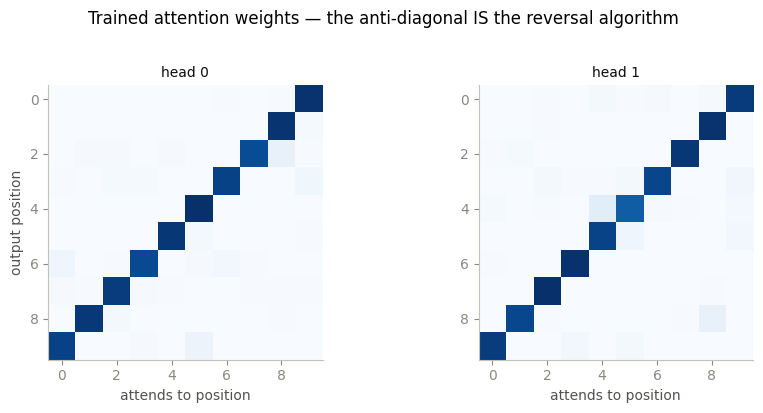

In [32]:
tf_model(demo)                                     # one forward to fill last_attn
attn = tf_model.block.attn.last_attn[0]            # (heads, T, T)
fig, axes = plt.subplots(1, HEADS, figsize=(9, 4))
for h, ax in enumerate(axes):
    ax.imshow(attn[h], cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"head {h}", fontsize=10); ax.grid(False)
    ax.set_xlabel("attends to position"); ax.set_ylabel("output position" if h == 0 else "")
plt.suptitle("Trained attention weights — the anti-diagonal IS the reversal algorithm", y=1.02)
plt.tight_layout()

The network *invented* the reversal algorithm: output position $i$ attends almost entirely
to input position $9{-}i$, and the value pathway carries that token through. This
interpretability — you can sometimes *read the learned program off the attention map* — is a
real research field (mechanistic interpretability). Scale this exact architecture to
$T{=}10^5$ tokens, $d{=}10^4$, ~100 blocks, causal masking, and train on "predict the next
token" over the internet: that's a GPT.

<a id="22"></a>
## 22. Autoencoders: learning without labels

An **autoencoder** is trained to output its own input through a narrow **bottleneck**:
$x \to \text{encode} \to z \to \text{decode} \to \hat x$, minimizing $\|x - \hat x\|^2$.
No labels needed. To reconstruct 64 pixels from just 2 numbers, the encoder must discover the
*factors of variation* — a free, task-agnostic representation. Uses: compression, denoising,
anomaly detection (reconstruction error flags weird inputs), and pretraining.

final reconstruction MSE: 0.0392 (through a 64 → 2 → 64 bottleneck)


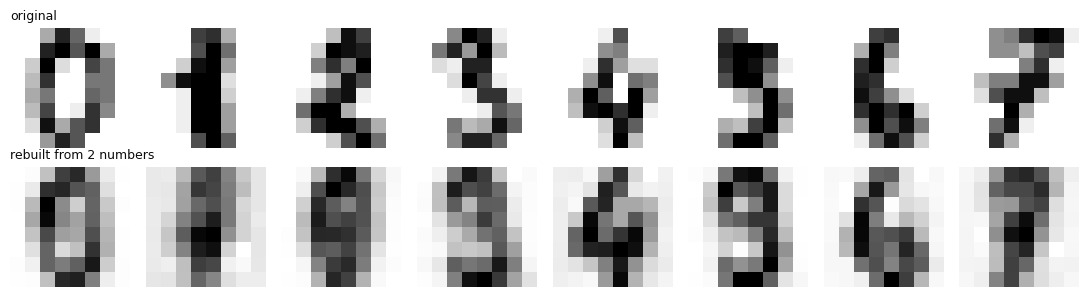

In [33]:
class AutoEncoder(nn.Module):
    def __init__(self, bottleneck=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, bottleneck))
        self.dec = nn.Sequential(nn.Linear(bottleneck, 32), nn.ReLU(), nn.Linear(32, 64))
    def forward(self, x):
        return self.dec(self.enc(x))

X_all_t = torch.tensor(X_all)
torch.manual_seed(0)
ae = AutoEncoder()
opt = torch.optim.Adam(ae.parameters(), lr=2e-3)
ae_dl = DataLoader(TensorDataset(X_all_t), batch_size=256, shuffle=True)
for ep in range(80):
    for (xb,) in ae_dl:
        loss = F.mse_loss(ae(xb), xb)
        opt.zero_grad(); loss.backward(); opt.step()
print(f"final reconstruction MSE: {loss.item():.4f} (through a 64 → 2 → 64 bottleneck)")

ae.eval()
with torch.no_grad():
    Z = ae.enc(X_all_t).numpy()
    recon = ae(X_all_t[:8]).numpy()

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for j in range(8):
    axes[0, j].imshow(X_all[j].reshape(8, 8), cmap="gray_r")
    axes[1, j].imshow(recon[j].reshape(8, 8), cmap="gray_r")
    axes[0, j].axis("off"); axes[1, j].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=9)
axes[1, 0].set_title("rebuilt from 2 numbers", loc="left", fontsize=9)
plt.tight_layout()

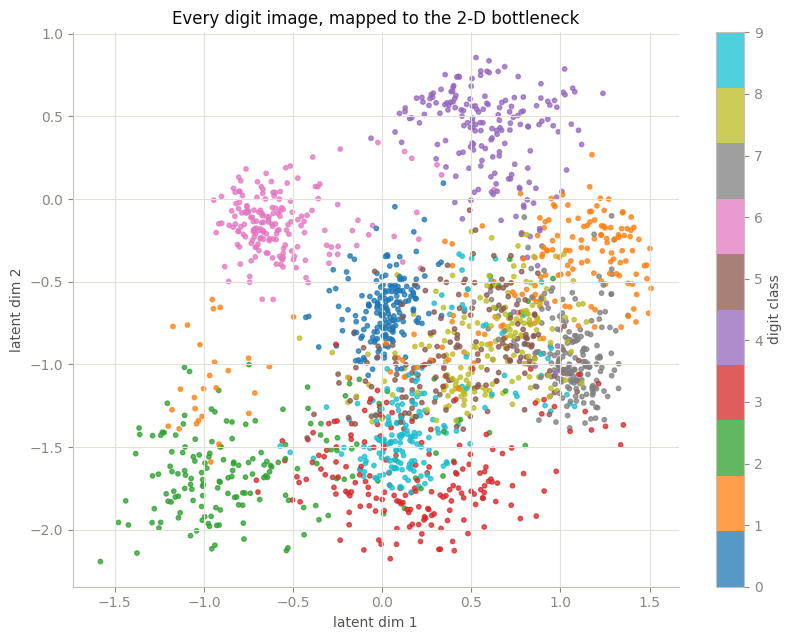

In [34]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sc = ax.scatter(Z[:, 0], Z[:, 1], c=y_all, cmap="tab10", s=10, alpha=.75)
cb = fig.colorbar(sc, ax=ax, ticks=range(10), label="digit class")
ax.set_xlabel("latent dim 1"); ax.set_ylabel("latent dim 2")
ax.set_title("Every digit image, mapped to the 2-D bottleneck")
plt.tight_layout()

The colors (class labels) were **never shown to the model**, yet same-digit images cluster
in the latent plane — reconstruction alone forced a semantic layout. Two famous upgrades:
**denoising AEs** (corrupt the input, reconstruct the clean version) and **VAEs**, which make
the latent space a smooth probability distribution you can *sample* from — a true generative
model, which brings us to GANs.

<a id="23"></a>
## 23. Generative adversarial networks

A **GAN** is a two-player game. The **generator** G turns random noise into fake samples; the
**discriminator** D tries to tell fake from real. Each gradient update makes D a better
detective and G a better forger; at equilibrium G's samples are indistinguishable from data.
No reconstruction, no likelihood — just adversarial pressure.

GANs are notoriously twitchy to train (mode collapse, oscillation), so watch one learn a
distribution we can fully see: a ring of 8 Gaussian blobs in 2-D.

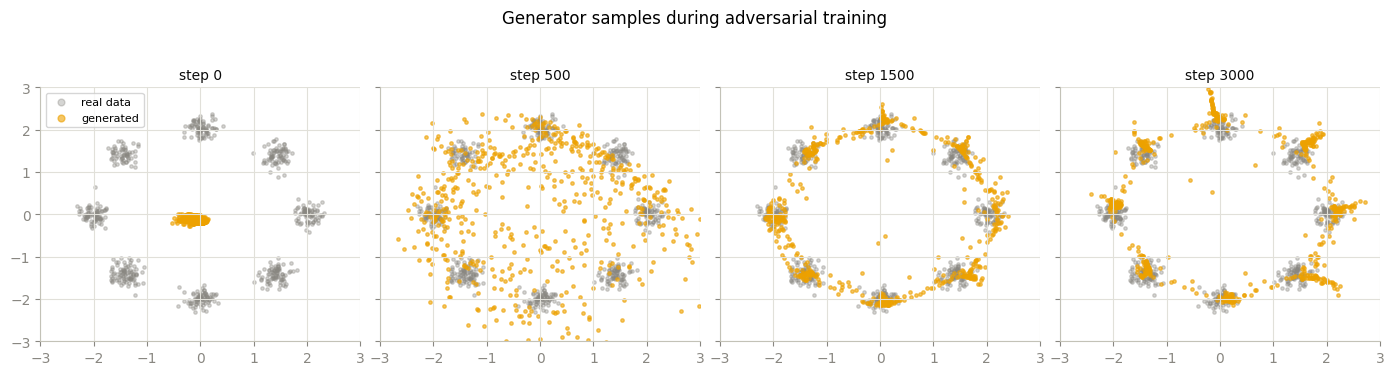

In [35]:
def real_batch(n):
    centers = np.stack([[2*np.cos(a), 2*np.sin(a)] for a in np.linspace(0, 2*np.pi, 9)[:-1]])
    pts = centers[rng.integers(0, 8, n)] + rng.normal(0, .15, (n, 2))
    return torch.tensor(pts, dtype=torch.float32)

torch.manual_seed(0)
G = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
D = nn.Sequential(nn.Linear(2, 64), nn.LeakyReLU(.2), nn.Linear(64, 64), nn.LeakyReLU(.2),
                  nn.Linear(64, 1))
opt_G = torch.optim.Adam(G.parameters(), lr=1e-3, betas=(.5, .999))
opt_D = torch.optim.Adam(D.parameters(), lr=1e-3, betas=(.5, .999))

snapshots, snap_at = {}, [0, 500, 1500, 3000]
for step in range(3001):
    if step in snap_at:
        with torch.no_grad():
            snapshots[step] = G(torch.randn(600, 2)).numpy()
    if step == 3000: break
    # --- train D: real → 1, fake → 0
    x_real, z = real_batch(128), torch.randn(128, 2)
    x_fake = G(z).detach()                       # detach: this step must not touch G
    loss_D = (F.binary_cross_entropy_with_logits(D(x_real), torch.ones(128, 1)) +
              F.binary_cross_entropy_with_logits(D(x_fake), torch.zeros(128, 1)))
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()
    # --- train G: fool D into saying 1
    loss_G = F.binary_cross_entropy_with_logits(D(G(torch.randn(128, 2))), torch.ones(128, 1))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True, sharey=True)
bg = real_batch(600).numpy()
for ax, step in zip(axes, snap_at):
    ax.scatter(*bg.T, s=6, color=GRAY, alpha=.35, label="real data")
    ax.scatter(*snapshots[step].T, s=6, color=PALETTE[2], alpha=.6, label="generated")
    ax.set_title(f"step {step}", fontsize=10); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
axes[0].legend(loc="upper left", fontsize=8, markerscale=2)
plt.suptitle("Generator samples during adversarial training", y=1.03)
plt.tight_layout()

From a formless blob, the generator finds the ring and then the individual modes — pushed
only by the discriminator's disapproval. If some blobs stay uncovered, that's **mode
collapse**, GAN failure mode #1 (rerun with another seed and you may see it). This exact
game, scaled up with convolutions, gave us StyleGAN's photorealistic faces; today's image
generators (Stable Diffusion, DALL·E) use **diffusion** instead — denoise pure noise step by
step — but the "generate from noise" framing was GANs' gift.

<a id="24"></a>
## 24. Transfer learning and self-supervised pretraining

The scarcest resource in machine learning is **labels** — raw data is usually abundant.
Modern practice exploits that asymmetry: **pretrain** a network on a cheap task that needs no
labels, then transfer its feature extractor to the real task and either

- **freeze** it and train just a new output head (best when labels are very scarce), or
- **fine-tune** everything at a low learning rate (needs more labels — small data can
  *wreck* good features).

This is precisely how LLMs work: pretrain on "predict the next token" (free labels!), then
fine-tune. Our miniature version: digits photographed by a **noisy sensor** (so raw pixels
are unreliable and features actually matter). We have ~660 *unlabeled* images and only a
handful of labeled ones. Pretext task: **denoising** — an autoencoder (§22) that maps a
corrupted image back to a clean one learns noise-robust stroke features, no labels involved.

denoising pretext trained on 672 unlabeled images, final MSE 0.0285


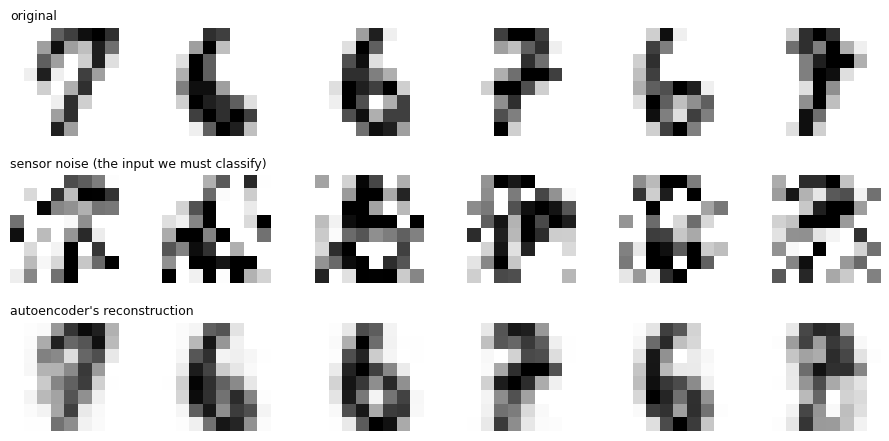

In [36]:
import copy

NOISE = 0.5
def corrupt(x, seed=None):
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    return (x + torch.randn(x.shape, generator=g) * NOISE).clamp(0, 1)

mask_hi = y_tr >= 5
Xhi, yhi = Xtr_t[mask_hi], (ytr_t[mask_hi] - 5)          # target task: digits 5–9
Xhi_te_n = corrupt(Xte_t[y_te >= 5], seed=99)            # deployment domain is noisy
yhi_te = torch.tensor(y_te[y_te >= 5] - 5)

# --- pretrain: denoising autoencoder on the UNLABELED pool (labels never touched)
torch.manual_seed(0)
encoder = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 32), nn.ReLU())
decoder = nn.Sequential(nn.Linear(32, 128), nn.ReLU(), nn.Linear(128, 64))
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=2e-3)
for step in range(1500):
    xb = Xhi[torch.randint(0, len(Xhi), (128,))]
    loss = F.mse_loss(decoder(encoder(corrupt(xb))), xb)  # noisy in → clean out
    opt.zero_grad(); loss.backward(); opt.step()
print(f"denoising pretext trained on {len(Xhi)} unlabeled images, final MSE {loss.item():.4f}")

with torch.no_grad():
    demo_noisy = corrupt(Xhi[:6], seed=1)
    demo_clean = decoder(encoder(demo_noisy))
fig, axes = plt.subplots(3, 6, figsize=(9, 4.6))
for j in range(6):
    for r, im in enumerate([Xhi[j], demo_noisy[j], demo_clean[j]]):
        axes[r, j].imshow(im.reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
        axes[r, j].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=9)
axes[1, 0].set_title("sensor noise (the input we must classify)", loc="left", fontsize=9)
axes[2, 0].set_title("autoencoder's reconstruction", loc="left", fontsize=9)
plt.tight_layout()

from scratch                 0.449  0.478  0.585  0.699
frozen pretrained features   0.661  0.703  0.808  0.857
full fine-tune               0.583  0.583  0.681  0.741


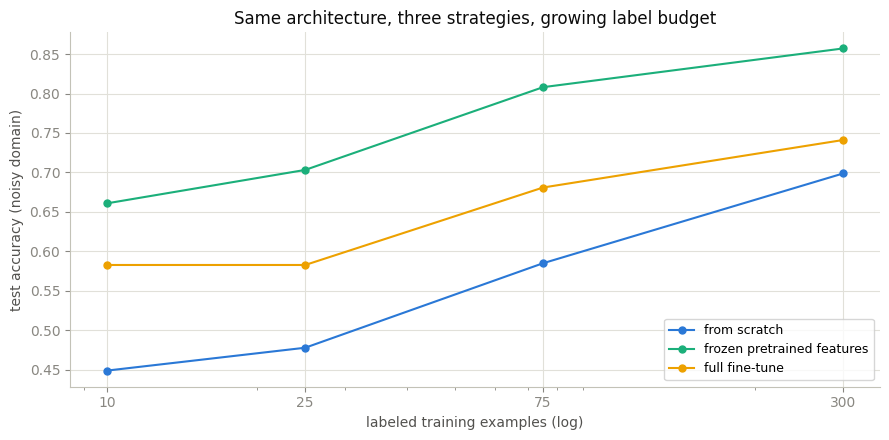

In [37]:
class EncoderClassifier(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.features = features
        self.head = nn.Linear(32, 5)
    def forward(self, x):
        return self.head(self.features(x))

def fresh_encoder():
    return nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 32), nn.ReLU())

strategies = [("from scratch", 3e-3), ("frozen pretrained features", 1e-2),
              ("full fine-tune", 1e-3)]
budgets = [2, 5, 15, 60]                          # labeled examples per class

results = {name: [] for name, _ in strategies}
for per_class in budgets:
    few = np.concatenate([np.flatnonzero(yhi.numpy() == c)[:per_class] for c in range(5)])
    dl_few = DataLoader(TensorDataset(corrupt(Xhi[few], seed=7), yhi[few]),
                        batch_size=32, shuffle=True)
    for name, lr in strategies:
        accs = []
        for seed in (1, 2):                       # average out few-shot luck
            torch.manual_seed(seed)
            feats = fresh_encoder() if name == "from scratch" else copy.deepcopy(encoder)
            m = EncoderClassifier(feats)
            if name == "frozen pretrained features":
                for p in m.features.parameters(): p.requires_grad_(False)
            opt = torch.optim.Adam([p for p in m.parameters() if p.requires_grad], lr=lr)
            h = train_classifier(m, dl_few, Xhi_te_n, yhi_te, epochs=100, optimizer=opt)
            accs.append(h["val_acc"][-1])
        results[name].append(np.mean(accs))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (name, _) in enumerate(strategies):
    ax.plot([5*b for b in budgets], results[name], marker="o", ms=5,
            color=PALETTE[i], label=name)
ax.set_xscale("log"); ax.set_xticks([10, 25, 75, 300], [10, 25, 75, 300])
ax.set_xlabel("labeled training examples (log)"); ax.set_ylabel("test accuracy (noisy domain)")
ax.set_title("Same architecture, three strategies, growing label budget")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
for name, _ in strategies:
    print(f"{name:<28} " + "  ".join(f"{a:.3f}" for a in results[name]))

Pretrained features dominate at **every** label budget, and most where it matters — with
10 labels the frozen encoder beats from-scratch by ~20 points, because the unlabeled
denoising task already taught it what strokes look like under noise; the 10 labels only have
to name the classes. Note also that *full fine-tuning trails frozen features here*: with so
few labels, updating the whole network lets gradient noise erode the pretrained weights.
The working rules: **tiny labeled set → freeze; moderate → fine-tune gently; huge → scratch
eventually catches up.** This plot is the economics of modern AI — foundation models (GPT,
CLIP, ResNet weights) are pretrained once on unlabeled data at enormous cost precisely so
everyone else can climb onto the green curve.

<a id="25"></a>
## 25. Debugging neural networks

Networks fail *silently* — wrong shapes broadcast, dead units sit at zero, and the loss just
quietly refuses to fall. A field-tested checklist:

1. **Overfit one batch first.** A correct model+loss+optimizer must reach ~0 loss on 64
   examples. If it can't, the wiring is broken — no point training on the full set.
2. **Watch layer health**: activation stats (hooks), fraction of dead ReLUs, gradient norms
   per layer (vanishing? exploding?).
3. **Clip gradients** (`clip_grad_norm_`) for RNNs/Transformers; hunt NaNs with
   `torch.autograd.set_detect_anomaly(True)`.
4. Fix seeds while debugging; change one thing at a time.

In [38]:
# 1) The overfit-one-batch smoke test
torch.manual_seed(0)
probe = CNN()
xb, yb = next(iter(train_img_dl))
opt = torch.optim.Adam(probe.parameters(), lr=3e-3)
for i in range(200):
    loss = F.cross_entropy(probe(xb), yb)
    opt.zero_grad(); loss.backward(); opt.step()
print(f"one-batch loss after 200 steps: {loss.item():.5f}  "
      f"{'← PASS: pipeline can learn' if loss.item() < 0.01 else '← FAIL: check wiring!'}")

one-batch loss after 200 steps: 0.00323  ← PASS: pipeline can learn


parameter audit: 42,634 total
  net.0.weight     (128, 64)      8,192
  net.0.bias       (128,)           128
  net.3.weight     (128, 128)    16,384
  net.3.bias       (128,)           128
  net.6.weight     (128, 128)    16,384
  net.6.bias       (128,)           128
  net.9.weight     (10, 128)      1,280
  net.9.bias       (10,)             10


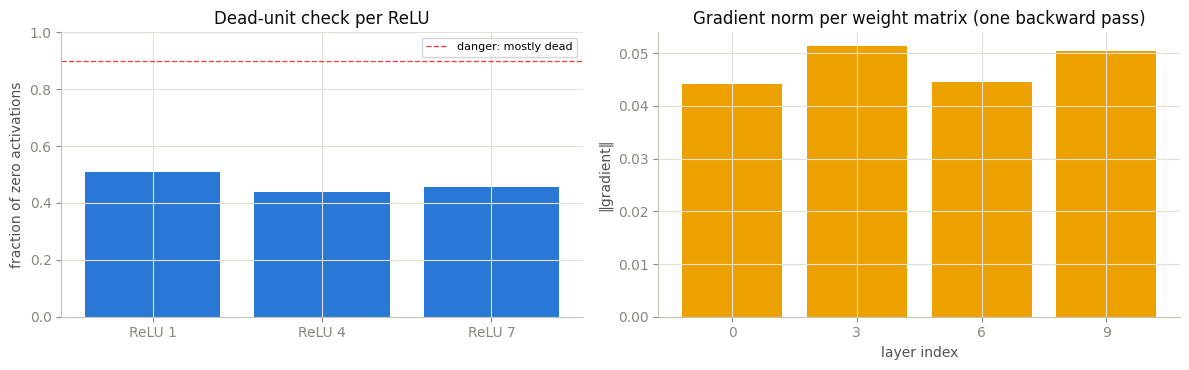

In [39]:
# 2) X-ray a forward/backward pass with hooks
stats = []
def spy(name):
    def hook(module, inp, out):
        a = out.detach()
        stats.append({"layer": name, "std": a.std().item(),
                      "dead": (a <= 0).float().mean().item()})
    return hook

torch.manual_seed(0)
probe2 = MLP((64, 128, 128, 128, 10))
hooks = [m.register_forward_hook(spy(f"ReLU {i}"))
         for i, m in enumerate(probe2.net) if isinstance(m, nn.ReLU)]
loss = F.cross_entropy(probe2(Xtr_t[:256]), ytr_t[:256])
loss.backward()
for h in hooks: h.remove()

gnorm = [(n, p.grad.norm().item()) for n, p in probe2.named_parameters() if "weight" in n]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax1.bar([s["layer"] for s in stats], [s["dead"] for s in stats], color=PALETTE[0])
ax1.axhline(0.9, color=PALETTE[5], ls="--", lw=1, label="danger: mostly dead")
ax1.set_ylabel("fraction of zero activations"); ax1.set_title("Dead-unit check per ReLU")
ax1.set_ylim(0, 1); ax1.legend(fontsize=8)
ax2.bar([n.split('.')[1] for n, _ in gnorm], [g for _, g in gnorm], color=PALETTE[2])
ax2.set_ylabel("‖gradient‖"); ax2.set_xlabel("layer index")
ax2.set_title("Gradient norm per weight matrix (one backward pass)")
plt.tight_layout()

total = sum(p.numel() for p in probe2.parameters())
print(f"parameter audit: {total:,} total")
for n, p in probe2.named_parameters():
    print(f"  {n:<16} {tuple(p.shape)!s:<12} {p.numel():>7,}")

Healthy numbers here: ~50% zeros per ReLU (by construction half the pre-activations are
negative at init — 90%+ means dying units), and gradient norms within a couple orders of
magnitude of each other across layers. When these charts go pathological, you now know which
section to revisit: init (§12), normalization (§14), or the learning rate (§6, §15).

<a id="26"></a>
## 26. Custom autograd functions and gradient checking

Sometimes you need an operation PyTorch doesn't have — a custom activation, a
non-differentiable estimator, a fused kernel. Subclass `torch.autograd.Function`, write the
forward *and its exact derivative*, and your op joins the §10 graph like any built-in. Then
**prove the derivative right** with `gradcheck`, which compares it to finite differences in
float64 — the industrial version of what we did by hand in §7.

In [40]:
class SoftClip(torch.autograd.Function):
    '''softclip(x) = x / (1 + |x|)  — a smooth squashing to (-1, 1).'''
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return x / (1 + x.abs())
    @staticmethod
    def backward(ctx, grad_out):
        (x,) = ctx.saved_tensors
        return grad_out / (1 + x.abs())**2      # d/dx [x/(1+|x|)] = 1/(1+|x|)²

x = torch.randn(6, dtype=torch.float64, requires_grad=True)
ok = torch.autograd.gradcheck(SoftClip.apply, (x,), eps=1e-6, atol=1e-8)
print("gradcheck (analytic vs finite differences, float64):", ok)

class SoftClipLayer(nn.Module):                  # drop it into any model
    def forward(self, x): return SoftClip.apply(x)

torch.manual_seed(0)
weird_net = nn.Sequential(nn.Linear(64, 64), SoftClipLayer(), nn.Linear(64, 10))
loss = F.cross_entropy(weird_net(Xtr_t[:128]), ytr_t[:128])
loss.backward()
print("custom op trains like any other — first-layer grad norm:",
      f"{weird_net[0].weight.grad.norm().item():.4f}")

gradcheck (analytic vs finite differences, float64): True
custom op trains like any other — first-layer grad norm: 0.2275


<a id="27"></a>
## 27. Saving, loading, and exporting models

Three artifacts you'll ship, in increasing portability:

1. **`state_dict`** — just the weights. The idiomatic PyTorch save (code defines the
   architecture; the file holds numbers).
2. **Checkpoint** — weights + optimizer state + epoch + metrics, so training can *resume*
   exactly (optimizers like Adam carry momentum state you'd otherwise lose).
3. **ONNX** — a framework-neutral graph that runs without PyTorch (ONNX Runtime, TensorRT,
   browsers, phones). The standard hand-off from research to production.

In [41]:
import os, tempfile
import onnx

savedir = tempfile.mkdtemp()

# 1) weights only
p1 = os.path.join(savedir, "mlp_weights.pt")
torch.save(mlp.state_dict(), p1)
mlp_reloaded = MLP()
mlp_reloaded.load_state_dict(torch.load(p1, weights_only=True))
same = torch.equal(mlp(Xte_t[:32]).argmax(1), mlp_reloaded(Xte_t[:32]).argmax(1))
print(f"state_dict roundtrip: {os.path.getsize(p1)/1e3:.0f} KB, predictions identical: {same}")

# 2) resumable checkpoint
opt = torch.optim.Adam(mlp.parameters())
p2 = os.path.join(savedir, "checkpoint.pt")
torch.save({"epoch": 30, "model": mlp.state_dict(), "optimizer": opt.state_dict(),
            "test_acc": mlp_test_acc}, p2)
ckpt = torch.load(p2, weights_only=True)
print(f"checkpoint keys: {list(ckpt)} (resume with epoch={ckpt['epoch']}, "
      f"acc={ckpt['test_acc']:.4f})")

# 3) ONNX export
p3 = os.path.join(savedir, "mlp.onnx")
mlp.eval()
torch.onnx.export(mlp, torch.randn(1, 64), p3, input_names=["pixels"],
                  output_names=["logits"], dynamic_axes={"pixels": {0: "batch"}})
onnx_model = onnx.load(p3)
onnx.checker.check_model(onnx_model)
print(f"ONNX graph valid ✓ — {len(onnx_model.graph.node)} nodes:",
      [n.op_type for n in onnx_model.graph.node])

state_dict roundtrip: 72 KB, predictions identical: True
checkpoint keys: ['epoch', 'model', 'optimizer', 'test_acc'] (resume with epoch=30, acc=0.9578)


ONNX graph valid ✓ — 5 nodes: ['Gemm', 'Relu', 'Gemm', 'Relu', 'Gemm']


<a id="28"></a>
## 28. Capstone: a full training pipeline

Everything in one place, done properly: a **three-way split** (train / validation for
decisions / test touched exactly once), a CNN with **BatchNorm + dropout**, **AdamW +
OneCycle**, **early stopping** that keeps the best weights, and an honest error analysis at
the end. This cell is the template to copy into your own projects.

early stop at epoch 25 (no val improvement for 12 epochs)
best val acc 0.9951 @ epoch 13 | FINAL TEST ACC 0.9911  (MLP §11: 0.9578)


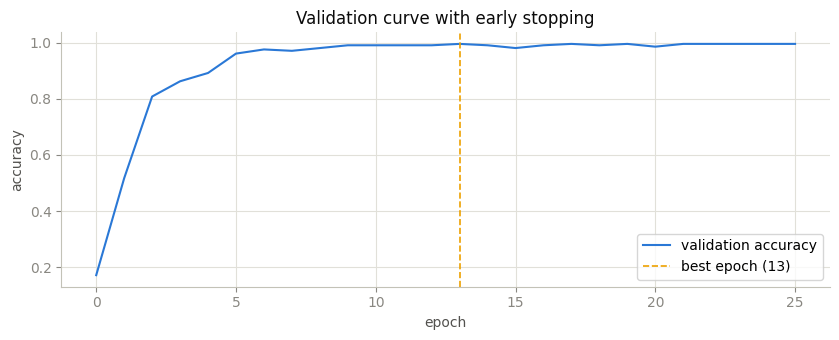

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

# --- three-way split: test set stays untouched until the very last line
Xtr2, Xval, ytr2, yval = train_test_split(X_tr, y_tr, test_size=0.15,
                                          stratify=y_tr, random_state=1)
tr_dl = DataLoader(TensorDataset(torch.tensor(Xtr2).reshape(-1, 1, 8, 8),
                                 torch.tensor(ytr2)), batch_size=64, shuffle=True)
Xval_t = torch.tensor(Xval).reshape(-1, 1, 8, 8); yval_t = torch.tensor(yval)

class DigitsNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(32*2*2, 10))
    def forward(self, x):
        return self.head(self.features(x))

EPOCHS, PATIENCE = 60, 12
torch.manual_seed(0)
model = DigitsNet()
opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=5e-3, total_steps=EPOCHS*len(tr_dl))

best = {"acc": 0.0, "epoch": -1, "state": None}
curve = []
for ep in range(EPOCHS):
    model.train()
    for xb, yb in tr_dl:
        loss = F.cross_entropy(model(xb), yb, label_smoothing=0.05)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
    va = accuracy(model, Xval_t, yval_t)
    curve.append(va)
    if va > best["acc"]:
        best = {"acc": va, "epoch": ep, "state": copy.deepcopy(model.state_dict())}
    elif ep - best["epoch"] >= PATIENCE:
        print(f"early stop at epoch {ep} (no val improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best["state"])              # rewind to the best checkpoint
test_acc = accuracy(model, Xte_img, yte_t)
print(f"best val acc {best['acc']:.4f} @ epoch {best['epoch']} | "
      f"FINAL TEST ACC {test_acc:.4f}  (MLP §11: {mlp_test_acc:.4f})")

fig, ax = plt.subplots(figsize=(8.5, 3.5))
ax.plot(curve, color=PALETTE[0], label="validation accuracy")
ax.axvline(best["epoch"], color=PALETTE[2], ls="--", lw=1.2,
           label=f"best epoch ({best['epoch']})")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend(loc="lower right")
ax.set_title("Validation curve with early stopping")
plt.tight_layout()

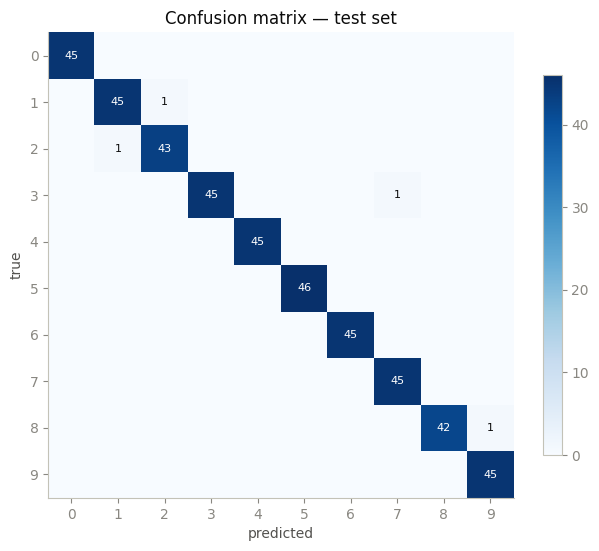

4 errors out of 450


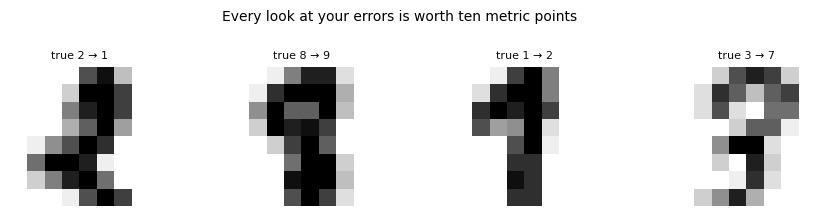

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        45
           1      0.978     0.978     0.978        46
           2      0.977     0.977     0.977        44
           3      1.000     0.978     0.989        46
           4      1.000     1.000     1.000        45
           5      1.000     1.000     1.000        46
           6      1.000     1.000     1.000        45
           7      0.978     1.000     0.989        45
           8      1.000     0.977     0.988        43
           9      0.978     1.000     0.989        45

    accuracy                          0.991       450
   macro avg      0.991     0.991     0.991       450
weighted avg      0.991     0.991     0.991       450



In [43]:
model.eval()
with torch.no_grad():
    pred = model(Xte_img).argmax(1).numpy()

cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max()/2 else "#0b0b0b")
ax.set_xticks(range(10)); ax.set_yticks(range(10)); ax.grid(False)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix — test set")
fig.colorbar(im, ax=ax, shrink=.8)
plt.tight_layout()
plt.show()

wrong = np.flatnonzero(pred != y_te)
print(f"{len(wrong)} errors out of {len(y_te)}")
if len(wrong):
    fig, axes = plt.subplots(1, min(8, len(wrong)), figsize=(11, 1.8))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, wrong):
        ax.imshow(X_te[i].reshape(8, 8), cmap="gray_r"); ax.axis("off")
        ax.set_title(f"true {y_te[i]} → {pred[i]}", fontsize=8)
    plt.suptitle("Every look at your errors is worth ten metric points", y=1.2, fontsize=10)
    plt.show()

print(classification_report(y_te, pred, digits=3))

Look at the misclassified images — most are ones a human would also squint at. That's the
sign of a model near this dataset's ceiling; the remaining wins come from data (more of it,
cleaner labels, augmentation), not from architecture tweaks. Knowing *which* lever to pull
next is most of the job.

<a id="29"></a>
## 29. Where to go from here

You now own the full core loop of deep learning: neurons → backprop (by hand!) → optimizers →
regularization and normalization → CNNs, RNNs/LSTMs, attention and a working Transformer →
autoencoders and GANs → transfer learning and production training craft. Everything else in
the field is these ideas, composed and scaled.

**Deepen the foundations**
- *Neural Networks: Zero to Hero* (Karpathy, YouTube) — builds micrograd (§10) and GPT (§21) live
- *Dive into Deep Learning* (d2l.ai) — free, runnable book; *Deep Learning* (Goodfellow et al.) for theory
- Papers worth reading in the original: ResNet (2015), *Attention Is All You Need* (2017),
  Adam (2014), BatchNorm (2015)

**Build things**
- Fashion-MNIST / CIFAR-10 with a ResNet you write yourself (residual blocks = §21's trick in CNNs)
- Karpathy's nanoGPT: a real (small) language model with exactly §21's architecture, causal-masked
- A Kaggle competition — nothing teaches regularization like a leaderboard

**Modern frontiers to explore next**
- **Diffusion models** (image generation), **contrastive learning** (CLIP-style, self-supervised),
  **RLHF / fine-tuning LLMs** (LoRA makes §24 cheap enough for a laptop)
- For real workloads: a GPU (Colab is free) and mixed-precision training (`torch.amp`)

*Other notebooks in this series:* `numpy_basics_to_expert` · `pandas_basics_to_expert` ·
`sklearn_basics_to_expert` · `machine_learning_basics_to_expert` · `pytorch_basics_to_expert` ·
`opencv_basics_to_expert`.